[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/danpele/MFM/blob/main/notebooks/EN/chapter16_lecture_notebook.ipynb)

# Modelling Financial Markets — Chapter 16: Digital Assets and DeFi

*Lecture notebook. Daniel Traian Pele, Bucharest University of Economic Studies.*

This notebook reproduces every chart and table of Lecture 16: the crypto market, stylised facts, a CRIX-style index, stablecoins, automated market makers, spot ETFs, crypto equities and the asset-class map.

> **Working in Google Colab? Save your own copy first.**
> The Colab link opens a temporary copy: when you close the tab or the session times out, your changes are lost.
> Use **File → Save a copy in Drive** (it goes to the *Colab Notebooks* folder of your ASE Google Drive) and work in that copy.
> For the team project, **File → Save a copy in GitHub** puts the notebook directly in your team's repository.
> Files you create while the notebook runs (CSV, charts) are also temporary: set `SAVE_TO_DRIVE = True` in the next cell to keep them.

In [ ]:
# Optional (Colab only): keep the files you create in Google Drive
SAVE_TO_DRIVE = False   # set to True, run this cell and allow access to your Drive

import os
OUT_DIR = '.'
if SAVE_TO_DRIVE:
    from google.colab import drive
    drive.mount('/content/drive')
    OUT_DIR = '/content/drive/MyDrive/MFM/Chapter_16'
    os.makedirs(OUT_DIR, exist_ok=True)
print('Save your outputs to:', os.path.abspath(OUT_DIR))


In [1]:
import os
import json
import time
import urllib.request
import urllib.parse
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from scipy import stats
from scipy.signal import lfilter
import statsmodels.api as sm
import warnings
warnings.filterwarnings('ignore')

## Style and helpers

In [2]:
# Chart style: transparent background, legend below the plot
plt.rcParams['figure.facecolor'] = 'none'
plt.rcParams['axes.facecolor'] = 'none'
plt.rcParams['savefig.facecolor'] = 'none'
plt.rcParams['savefig.transparent'] = True
plt.rcParams['axes.grid'] = False
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['font.sans-serif'] = ['Helvetica', 'Arial', 'DejaVu Sans']
plt.rcParams['font.size'] = 9
plt.rcParams['axes.labelsize'] = 10
plt.rcParams['axes.titlesize'] = 11
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False
plt.rcParams['axes.linewidth'] = 0.6
plt.rcParams['lines.linewidth'] = 1.1
plt.rcParams['legend.facecolor'] = 'none'
plt.rcParams['legend.framealpha'] = 0
plt.rcParams['legend.fontsize'] = 8

# Course colours (no grey: navy reference lines, light-blue bands)
MainBlue = '#1A3A6E'
IDAred   = '#CD0000'
Forest   = '#2E7D32'
Amber    = '#B5853F'
Orange   = '#E67E22'
Purple   = '#8E44AD'
Crimson  = '#DC3545'
Teal     = '#17A2B8'
Magenta  = '#D63384'
Brown    = '#795548'
Navy     = '#1F2A44'   # reference lines (no grey in charts)
BandBlue = '#C5D2E8'   # light MainBlue tint for confidence / reference bands
Gray, LightGray = Navy, BandBlue   # legacy names kept for importing scripts
COL = {'BTC': Orange, 'ETH': Purple, 'XRP': MainBlue, 'ADA': Forest, 'DOGE': Amber, 'LTC': Teal, 'LINK': IDAred,
       'SOL': Magenta, 'BNB': Brown, 'SPX': MainBlue, 'GOLD': Amber, 'QQQ': Teal, 'USDT': Forest, 'USDC': MainBlue,
       'DAI': Orange, 'IBIT': MainBlue, 'ETHA': Purple, 'COIN': MainBlue, 'MSTR': IDAred, 'TLT': Forest}
CLASS_COL = {'Crypto': Orange, 'Equity': MainBlue, 'FX': Forest, 'Commodity': Amber, 'Bond': Purple}

HERE = '.'
SEED = 42
ETF_START = '2024-01-11'
B_BOOT = 2000


def save_fig(name):
    """Save the figure as a transparent PDF and PNG in the current folder."""
    plt.savefig(f'{name}.pdf', bbox_inches='tight', transparent=True)
    plt.savefig(f'{name}.png', bbox_inches='tight', transparent=True, dpi=180)
    plt.show()
    plt.close()
    print(f"   saved {name}")


def legend_outside_bottom(ax, ncol=2, y=-0.22):
    """Place the legend outside the plot, bottom centre."""
    ax.legend(loc='upper center', bbox_to_anchor=(0.5, y), ncol=ncol, frameon=False)


def fig_legend_bottom(fig, handles=None, labels=None, ncol=4, y=0.0):
    """A single legend below a multi-panel figure."""
    if handles is None:
        handles, labels = [], []
        for ax in fig.axes:
            for h, l in zip(*ax.get_legend_handles_labels()):
                if l not in labels and not l.startswith('_'):
                    handles.append(h)
                    labels.append(l)
    fig.legend(handles, labels, loc='upper center', bbox_to_anchor=(0.5, y), ncol=ncol, frameon=False)


def jsonable(x):
    """Recursively convert numpy numbers and dates to JSON types."""
    if isinstance(x, dict):
        return {str(k): jsonable(v) for k, v in x.items()}
    if isinstance(x, (list, tuple)):
        return [jsonable(v) for v in x]
    if isinstance(x, (np.floating, float)):
        return None if not np.isfinite(x) else float(x)
    if isinstance(x, (np.integer,)):
        return int(x)
    if isinstance(x, (pd.Timestamp,)):
        return str(x.date())
    return x


def max_drawdown(p):
    """Largest fall from a previous peak (in %) and the date of the trough."""
    dd = p / p.cummax() - 1
    return 100 * dd.min(), dd.idxmin()


def hill(x, frac=0.05):
    """Hill estimator of the tail index from the largest frac of the positive values of x."""
    x = np.sort(x[x > 0])[::-1]
    k = max(int(frac * len(x)), 10)
    return 1 / np.mean(np.log(x[:k] / x[k]))


def hac_ols(y, X, lags=4):
    """OLS regression with Newey-West (HAC) standard errors."""
    return sm.OLS(y, sm.add_constant(X)).fit(cov_type='HAC', cov_kwds={'maxlags': lags})


import tempfile
# SAVE_TO_DRIVE = True (Colab cell above): charts and tables go to OUT_DIR in Google Drive; otherwise tables go to a temporary folder
KEEP = bool(globals().get('SAVE_TO_DRIVE', False))
HERE = globals().get('OUT_DIR', '.') if KEEP else tempfile.gettempdir()


def save_fig(name):
    """Show the figure; with SAVE_TO_DRIVE, also save it as PNG in OUT_DIR."""
    if KEEP:
        plt.savefig(os.path.join(HERE, f'{name}.png'), bbox_inches='tight', transparent=True, dpi=180)
    plt.show()
    plt.close()


def _get(d, key):
    for part in key.split('/'):
        d = d[part]
    return d


def _fmt(v, digits=3):
    if isinstance(v, (bool, np.bool_)):
        return str(v)
    if isinstance(v, (int, np.integer)):
        return f'{int(v):,}'
    if isinstance(v, (float, np.floating)):
        return f'{float(v):,.{digits}f}'
    if isinstance(v, (list, tuple, np.ndarray)):
        return '[' + ', '.join(_fmt(x, digits) for x in v) + ']'
    return str(v)


def show(d, labels, digits=3, title=None):
    """Print selected results, one labelled line each."""
    if title:
        print(title)
    w = max(len(lab) for lab in labels.values())
    for k, lab in labels.items():
        print(f'  {lab:<{w}}  {_fmt(_get(d, k), digits)}')


def table(d, rows, cols=None, digits=3):
    """Table of selected results: rows with descriptive labels, columns renamed."""
    df = d if isinstance(d, pd.DataFrame) else pd.DataFrame(d)
    df = df.loc[list(rows)].rename(index=rows)
    if cols:
        df = df[list(cols)].rename(columns=cols)
    return df.apply(lambda c: c.map(lambda v: round(float(v), digits) if isinstance(v, (float, np.floating)) else v))

## Data

- Daily closes up to 18 September 2026: crypto-assets 7 days a week; ETFs and shares on weekdays, adjusted for dividends and splits.
- Coins in circulation: Coin Metrics Community Data; DeFi total value locked and stablecoin supply: DefiLlama.
- Analyses that combine assets use common days: prices are aligned on common trading days first, then returns are computed.

In [3]:
REPO_RAW = 'https://raw.githubusercontent.com/danpele/MFM/main/data/market/'
# read the course data
MARKET_DIR = next((os.path.join(d, 'data', 'market') for d in ('.', '..', '../..', '../../..')
                   if os.path.isdir(os.path.join(d, 'data', 'market'))), '')
END = '2026-09-18'

# key -> (symbol, label, type, Coin Metrics id)
ASSETS = {
    'BTC': ('BTC-USD.CC', 'Bitcoin', 'crypto', 'btc'),
    'ETH': ('ETH-USD.CC', 'Ethereum', 'crypto', 'eth'),
    'XRP': ('XRP-USD.CC', 'XRP', 'crypto', 'xrp'),
    'BNB': ('BNB-USD.CC', 'BNB', 'crypto', None),
    'SOL': ('SOL-USD.CC', 'Solana', 'crypto', None),
    'ADA': ('ADA-USD.CC', 'Cardano', 'crypto', 'ada'),
    'DOGE': ('DOGE-USD.CC', 'Dogecoin', 'crypto', 'doge'),
    'LTC': ('LTC-USD.CC', 'Litecoin', 'crypto', 'ltc'),
    'LINK': ('LINK-USD.CC', 'Chainlink', 'crypto', 'link'),
    'USDT': ('USDT-USD.CC', 'Tether (USDT)', 'crypto', None),
    'USDC': ('USDC-USD.CC', 'USD Coin (USDC)', 'crypto', None),
    'DAI': ('DAI-USD.CC', 'Dai', 'crypto', None),
    'IBIT': ('IBIT.US', 'IBIT (spot Bitcoin ETF)', 'etf', None),
    'ETHA': ('ETHA.US', 'ETHA (spot Ether ETF)', 'etf', None),
    'COIN': ('COIN.US', 'Coinbase', 'etf', None),
    'MSTR': ('MSTR.US', 'Strategy', 'etf', None),
    'QQQ': ('QQQ.US', 'Nasdaq 100 (QQQ)', 'etf', None),
    'GLD': ('GLD.US', 'Gold (GLD)', 'etf', None),
    'TLT': ('TLT.US', 'Long Treasuries (TLT)', 'etf', None),
    'SPX': ('GSPC.INDX', 'S&P 500', 'index', None),
    'GOLD': ('XAUUSD.FOREX', 'Gold (XAU/USD)', 'fx', None),
}
LABELS = {k: v[1] for k, v in ASSETS.items()}
# assets with a price series whose public current supply equals the circulating supply
# (XRP and Chainlink: the reported supply includes tokens held by the issuer; Solana, BNB: no public supply)
CRIX_UNIVERSE = ['BTC', 'ETH', 'DOGE', 'ADA', 'LTC']
STABLE = ['USDT', 'USDC', 'DAI']

_CACHE = {}
UA = {'User-Agent': 'Mozilla/5.0 (MFM course notebook)'}


def _get_json(url, tries=4):
    """Read a JSON response."""
    for i in range(tries):
        try:
            return json.load(urllib.request.urlopen(urllib.request.Request(url, headers=UA), timeout=120))
        except Exception:
            if i == tries - 1:
                raise
            time.sleep(3 * (i + 1))


def read_market(symbol):
    """Read the daily price series of one asset from the course data."""
    if symbol in _CACHE:
        return _CACHE[symbol]
    fname = f'{symbol}.csv'
    path = os.path.join(MARKET_DIR, fname)
    src = path if os.path.exists(path) else REPO_RAW + fname
    _CACHE[symbol] = pd.read_csv(src, index_col='date', parse_dates=True).sort_index()
    return _CACHE[symbol]


def price(key, start=None, end=END, col=None):
    """Cleaned daily price: crypto 7/7 (close), ETFs/shares (adjusted close), indices/FX (close) on weekdays."""
    symbol, _, kind, _ = ASSETS[key]
    d = read_market(symbol)
    col = col or ('adjusted_close' if kind == 'etf' else 'close')
    s = d[col].loc[start:end]
    s = s[s > 0].dropna()
    if kind != 'crypto':
        s = s[s.index.dayofweek < 5]
    if kind == 'index':
        s = s[s.diff() != 0]
    return s.rename(key)


def log_returns(key, start=None, end=END):
    """Log returns on the series' own calendar."""
    return np.log(price(key, start, end)).diff().dropna().rename(key)


def joint_prices(keys, start=None, end=END):
    """Prices of several assets on COMMON days (prices aligned first)."""
    return pd.concat([price(k, None, end) for k in keys], axis=1, join='inner').dropna().loc[start:]


def joint_returns(keys, start=None, end=END, freq=None):
    """Common log returns: align prices first, optional weekly (Friday) sampling, then returns."""
    p = joint_prices(keys, None, end)
    if freq == 'W':
        p = p.resample('W-FRI').last().dropna()
    return np.log(p).diff().dropna().loc[start:]


def periods_per_year(r):
    """Actual frequency: average number of observations per calendar year."""
    return len(r) / ((r.index[-1] - r.index[0]).days / 365.25)


def coin_supply(asset, start='2017-01-01', end=END):
    """Daily current supply (SplyCur) of a crypto-asset, from Coin Metrics Community Data."""
    key = ('supply', asset, start, end)
    if key in _CACHE:
        return _CACHE[key]
    url = ('https://community-api.coinmetrics.io/v4/timeseries/asset-metrics?assets=' + asset +
           f'&metrics=SplyCur&frequency=1d&start_time={start}&end_time={end}&page_size=10000')
    rows = []
    while url:
        js = _get_json(url)
        rows += js.get('data', [])
        url = js.get('next_page_url')
    s = pd.Series({pd.Timestamp(r['time'][:10]): float(r['SplyCur']) for r in rows}).sort_index()
    _CACHE[key] = s.rename(asset)
    return _CACHE[key]


def market_values(keys=CRIX_UNIVERSE, start='2018-01-01', end=END):
    """Daily market value = closing price x current supply, in billion USD."""
    out = {}
    for k in keys:
        p = price(k, start, end)
        s = coin_supply(ASSETS[k][3], start, end).reindex(p.index).ffill()
        out[k] = p * s / 1e9
    return pd.DataFrame(out).dropna()


def defi_tvl():
    """Total value locked (TVL) in DeFi protocols, all blockchains, billion USD (DefiLlama)."""
    if 'tvl' not in _CACHE:
        js = _get_json('https://api.llama.fi/v2/historicalChainTvl')
        s = pd.Series({pd.Timestamp(int(x['date']), unit='s').normalize(): x['tvl'] / 1e9 for x in js}).sort_index()
        _CACHE['tvl'] = s[s > 0].loc[:END].rename('TVL')
    return _CACHE['tvl']


def stablecoin_chart(sid=None):
    """Circulating supply (billion units) and its value (billion USD); sid=None: all USD stablecoins."""
    key = ('stable', sid)
    if key not in _CACHE:
        url = 'https://stablecoins.llama.fi/stablecoincharts/all' + (f'?stablecoin={sid}' if sid else '')
        js = _get_json(url)
        rows = {}
        for x in js:
            d = pd.Timestamp(int(x['date']), unit='s').normalize()
            c = (x.get('totalCirculating') or {}).get('peggedUSD')
            v = (x.get('totalCirculatingUSD') or {}).get('peggedUSD')
            if c is not None:
                rows[d] = (c / 1e9, (v if v is not None else np.nan) / 1e9)
        df = pd.DataFrame(rows, index=['supply', 'value']).T.sort_index()
        _CACHE[key] = df.loc[:END]
    return _CACHE[key]


def stablecoin_list():
    """Today's USD stablecoins: symbol, name, peg mechanism, supply (billion USD)."""
    if 'slist' not in _CACHE:
        js = _get_json('https://stablecoins.llama.fi/stablecoins?includePrices=false')['peggedAssets']
        rows = [dict(id=x['id'], symbol=x['symbol'], name=x['name'], mechanism=x.get('pegMechanism'),
                     supply=((x.get('circulating') or {}).get('peggedUSD') or 0) / 1e9)
                for x in js if x.get('pegType') == 'peggedUSD']
        _CACHE['slist'] = pd.DataFrame(rows).sort_values('supply', ascending=False).reset_index(drop=True)
    return _CACHE['slist']


def chain_tvl():
    """Today's TVL by blockchain, billion USD (DefiLlama)."""
    if 'chains' not in _CACHE:
        js = _get_json('https://api.llama.fi/v2/chains')
        s = pd.Series({x['name']: (x.get('tvl') or 0) / 1e9 for x in js}).sort_values(ascending=False)
        _CACHE['chains'] = s
    return _CACHE['chains']


def chain_tvl_at(name, date=END):
    """TVL of one blockchain on a date (last value up to that date), billion USD (DefiLlama)."""
    key = ('chain', name)
    if key not in _CACHE:
        js = _get_json('https://api.llama.fi/v2/historicalChainTvl/' + urllib.parse.quote(name))
        _CACHE[key] = pd.Series({pd.Timestamp(int(x['date']), unit='s').normalize(): x['tvl'] / 1e9 for x in js}).sort_index()
    s = _CACHE[key].loc[:date]
    return float(s.iloc[-1]) if len(s) else 0.0


# universe for the asset-class map (a reduced replication of Pele et al., 2023): symbol -> (label, class, type)
CLASS_ASSETS = {
    'BTC-USD.CC': ('Bitcoin', 'Crypto', 'crypto'), 'ETH-USD.CC': ('Ethereum', 'Crypto', 'crypto'),
    'XRP-USD.CC': ('XRP', 'Crypto', 'crypto'), 'LTC-USD.CC': ('Litecoin', 'Crypto', 'crypto'),
    'DOGE-USD.CC': ('Dogecoin', 'Crypto', 'crypto'), 'ADA-USD.CC': ('Cardano', 'Crypto', 'crypto'),
    'LINK-USD.CC': ('Chainlink', 'Crypto', 'crypto'), 'BNB-USD.CC': ('BNB', 'Crypto', 'crypto'),
    'GSPC.INDX': ('S&P 500', 'Equity', 'index'), 'NDX.INDX': ('Nasdaq 100', 'Equity', 'index'),
    'STOXX50E.INDX': ('Euro Stoxx 50', 'Equity', 'index'), 'GDAXI.INDX': ('DAX', 'Equity', 'index'),
    'N225.INDX': ('Nikkei 225', 'Equity', 'index'), 'BET': ('BET', 'Equity', 'index'),
    'EURUSD.FOREX': ('EUR/USD', 'FX', 'fx'), 'USDJPY.FOREX': ('USD/JPY', 'FX', 'fx'),
    'GBPUSD.FOREX': ('GBP/USD', 'FX', 'fx'), 'USDCHF.FOREX': ('USD/CHF', 'FX', 'fx'),
    'XAUUSD.FOREX': ('Gold', 'Commodity', 'fx'), 'USO.US': ('Oil (USO)', 'Commodity', 'etf'),
    'UNG.US': ('Natural gas (UNG)', 'Commodity', 'etf'), 'DBC.US': ('Commodities (DBC)', 'Commodity', 'etf'),
    'TLT.US': ('Long Treasuries (TLT)', 'Bond', 'etf'), 'IEF.US': ('7-10y Treasuries (IEF)', 'Bond', 'etf'),
    'LQD.US': ('Corporate IG (LQD)', 'Bond', 'etf'), 'HYG.US': ('High yield (HYG)', 'Bond', 'etf'),
}


def symbol_returns(symbol, start=None, end=END):
    """Daily log returns of a symbol from CLASS_ASSETS, on its own calendar."""
    _, _, kind = CLASS_ASSETS[symbol]
    d = read_market(symbol)
    s = d['adjusted_close' if kind == 'etf' else 'close'].loc[:end]
    s = s[s > 0].dropna()
    if kind != 'crypto':
        s = s[s.index.dayofweek < 5]
    if kind == 'index':
        s = s[s.diff() != 0]
    return np.log(s).diff().dropna().loc[start:end]

## 1. Market value and concentration

- Market value $M = P \times Q$ (price times coins in circulation); Bitcoin share; Herfindahl–Hirschman index $\mathrm{HHI} = \sum_i w_i^2$ ($w_i$: market-value shares).

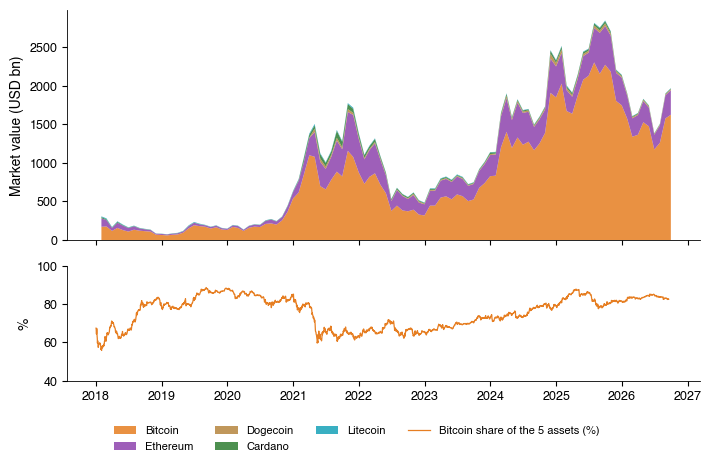

  Market value of the five coins, end of sample (billion USD)  1,970.20
  Peak market value (billion USD)                              3,135.04
  Date of the peak                                             2025-10-06
  Bitcoin share, end of sample (%)                             82.48
  Lowest Bitcoin share (%)                                     55.77
  Date of the lowest Bitcoin share                             2018-02-01
  Highest Bitcoin share (%)                                    88.52
  Date of the highest Bitcoin share                            2019-09-05
  Ether share, end of sample (%)                               16.18
  Herfindahl-Hirschman index (HHI), end of sample              0.71
  Effective number of coins, 1/HHI                             1.42


In [4]:
def fig_market_value():
    """Market value (price x current supply) of the assets in the index universe, 2018-2026."""
    mv = market_values()
    m = mv.resample('ME').last()
    tot = mv.sum(axis=1)
    share = 100 * mv['BTC'] / tot
    fig, axes = plt.subplots(2, 1, figsize=(7.2, 4.2), sharex=True, gridspec_kw={'height_ratios': [2, 1]})
    axes[0].stackplot(m.index, [m[k] for k in CRIX_UNIVERSE], labels=[LABELS[k] for k in CRIX_UNIVERSE],
                      colors=[COL[k] for k in CRIX_UNIVERSE], alpha=0.85, lw=0)
    axes[0].set_ylabel('Market value (USD bn)')
    axes[1].plot(share.index, share.values, color=Orange, lw=0.9, label=f'Bitcoin share of the {len(CRIX_UNIVERSE)} assets (%)')
    axes[1].set_ylabel('%')
    axes[1].set_ylim(40, 100)
    fig.tight_layout()
    fig_legend_bottom(fig, ncol=4, y=0.0)
    save_fig('ch16_market_value')
    hhi = ((mv.div(tot, axis=0)) ** 2).sum(axis=1)
    return dict(start=str(mv.index[0].date()), total_end=tot.iloc[-1], total_peak=tot.max(),
                total_peak_date=str(tot.idxmax().date()), btc_share_end=share.iloc[-1], btc_share_min=share.min(),
                btc_share_min_date=str(share.idxmin().date()), btc_share_max=share.max(),
                btc_share_max_date=str(share.idxmax().date()), eth_share_end=100 * mv['ETH'].iloc[-1] / tot.iloc[-1],
                hhi_end=hhi.iloc[-1], neff_end=1 / hhi.iloc[-1], mv_end={k: mv[k].iloc[-1] for k in CRIX_UNIVERSE},
                btc_price_end=price('BTC').iloc[-1], btc_supply_end=1e9 * mv['BTC'].iloc[-1] / price('BTC').iloc[-1],
                eth_price_end=price('ETH').iloc[-1], eth_supply_end=1e9 * mv['ETH'].iloc[-1] / price('ETH').iloc[-1],
                end=str(mv.index[-1].date()))


mv = fig_market_value()
show(mv, {'total_end': 'Market value of the five coins, end of sample (billion USD)',
 'total_peak': 'Peak market value (billion USD)',
 'total_peak_date': 'Date of the peak',
 'btc_share_end': 'Bitcoin share, end of sample (%)',
 'btc_share_min': 'Lowest Bitcoin share (%)',
 'btc_share_min_date': 'Date of the lowest Bitcoin share',
 'btc_share_max': 'Highest Bitcoin share (%)',
 'btc_share_max_date': 'Date of the highest Bitcoin share',
 'eth_share_end': 'Ether share, end of sample (%)',
 'hhi_end': 'Herfindahl-Hirschman index (HHI), end of sample',
 'neff_end': 'Effective number of coins, 1/HHI'}, digits=2)

## 2. Stylised facts: crypto vs shares and gold

In [5]:
STYL = ['BTC', 'ETH', 'SOL', 'DOGE', 'SPX', 'GOLD']


def stylised_table(start='2018-01-01'):
    """Moments, tails, autocorrelations, maximum drawdowns and historical VaR 1% / ES 2.5%, each series on its own calendar."""
    rows = {}
    for k in STYL:
        p = price(k, start)
        r = 100 * np.log(p).diff().dropna()
        ppy = periods_per_year(r)
        q = np.quantile(r, 0.01)
        q25 = np.quantile(r, 0.025)
        mdd, mdd_date = max_drawdown(p)
        rows[k] = dict(N=len(r), start=str(r.index[0].date()), ppy=ppy, ann_mean=r.mean() * ppy,
                       ann_vol=r.std() * np.sqrt(ppy), skew=stats.skew(r), kurt=stats.kurtosis(r),
                       acf1=r.autocorr(1), acf1_abs=r.abs().autocorr(1), var1=-q, es2_5=-r[r <= q25].mean(),
                       min=r.min(), min_date=str(r.idxmin().date()), mdd=mdd, mdd_date=str(mdd_date.date()),
                       hill_left=hill(-r.values), share5sd=100 * (np.abs(r - r.mean()) > 5 * r.std()).mean(),
                       # the same measures as simple losses, in % of the position: 1 - exp(r/100)
                       var1_simple=100 * (1 - np.exp(q / 100)),
                       es2_5_simple=100 * (1 - np.exp(r[r <= q25] / 100)).mean(),
                       min_simple=100 * (np.exp(r.min() / 100) - 1))
    t = pd.DataFrame(rows).T
    t.to_csv(os.path.join(HERE, 'ch16_stylised_facts.csv'))
    return t


t = stylised_table()
table(t.T, {'N': 'Returns',
 'ppy': 'Returns per year',
 'ann_mean': 'Mean (% a year)',
 'ann_vol': 'Volatility (% a year)',
 'skew': 'Skewness',
 'kurt': 'Excess kurtosis',
 'acf1': 'Autocorrelation, lag 1',
 'acf1_abs': 'Autocorrelation of |r|, lag 1',
 'var1': 'VaR 1% (log return, %)',
 'es2_5': 'ES 2.5% (log return, %)',
 'min': 'Worst day (log return, %)',
 'min_date': 'Date of the worst day',
 'mdd': 'Maximum drawdown (%)',
 'hill_left': 'Hill tail index, losses',
 'share5sd': 'Days beyond 5 standard deviations (%)',
 'var1_simple': 'VaR 1% (loss, % of the position)',
 'es2_5_simple': 'ES 2.5% (loss, % of the position)'}, {'BTC': 'Bitcoin', 'ETH': 'Ether', 'SOL': 'Solana', 'DOGE': 'Dogecoin', 'SPX': 'S&P 500', 'GOLD': 'Gold'})

,Bitcoin,Ether,Solana,Dogecoin,S&P 500,Gold
Returns,3182,3182,2351,3182,2189,2269
Returns per year,365.365,365.365,365.405,365.365,251.425,260.532
Mean (% a year),20.427,13.983,77.346,26.221,11.981,13.887
Volatility (% a year),64.121,84.337,117.063,123.921,19.188,17.206
Skewness,-0.946,-0.824,-0.219,4.876,-0.646,-0.548
Excess kurtosis,14.833,11.06,7.888,106.366,14.922,10.255
"Autocorrelation, lag 1",-0.047,-0.046,-0.042,0.027,-0.145,-0.021
"Autocorrelation of |r|, lag 1",0.168,0.155,0.277,0.371,0.357,0.126
"VaR 1% (log return, %)",10.224,13.488,14.462,13.791,3.43,2.999
"ES 2.5% (log return, %)",10.288,13.684,17.145,16.35,3.832,3.182


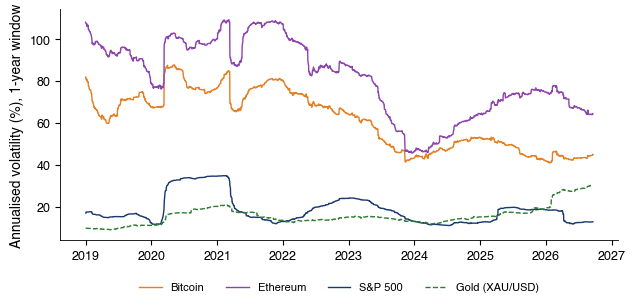

  Bitcoin: latest one-year volatility (% a year)  45.08
  Ether: latest one-year volatility (% a year)    64.50
  S&P 500: latest one-year volatility (% a year)  12.90
  Gold: latest one-year volatility (% a year)     30.31
  Bitcoin: lowest one-year volatility (% a year)  41.05
  Bitcoin: date of the lowest volatility          2026-01-19
  Bitcoin / S&P 500 volatility ratio, latest      3.49


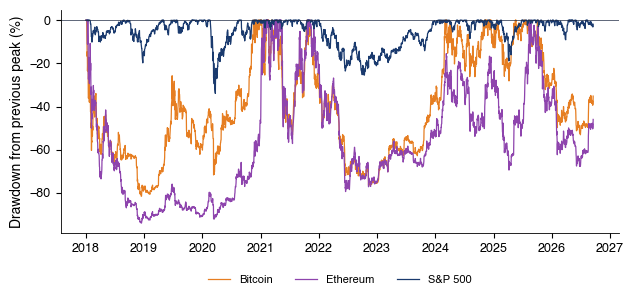

  Bitcoin: maximum drawdown (%)                            -81.53
  Bitcoin: date of the trough                              2018-12-15
  Bitcoin: days more than 50% below the previous peak (%)  36.38
  Ether: maximum drawdown (%)                              -93.96
  Ether: date of the trough                                2018-12-14
  Ether: days more than 50% below the previous peak (%)    61.26
  S&P 500: maximum drawdown (%)                            -33.92
  S&P 500: date of the trough                              2020-03-23


In [6]:
def fig_rolling_vol(start='2018-01-01'):
    """Annualised volatility over rolling one-calendar-year windows."""
    # distinct colours: gold (Forest, dashed line) is not confused with Bitcoin (Orange)
    VOL_COL = {'BTC': Orange, 'ETH': Purple, 'SPX': MainBlue, 'GOLD': Forest}
    VOL_LS = {'BTC': '-', 'ETH': '-', 'SPX': '-', 'GOLD': '--'}
    fig, ax = plt.subplots(figsize=(7.2, 3.0))
    out = {}
    for k in ['BTC', 'ETH', 'SPX', 'GOLD']:
        r = log_returns(k, start)
        ppy = periods_per_year(r)
        v = 100 * r.rolling('365D', min_periods=int(0.9 * ppy)).std() * np.sqrt(ppy)
        v = v.loc['2019-01-01':]
        ax.plot(v.index, v.values, color=VOL_COL[k], lw=1.0, ls=VOL_LS[k], label=LABELS[k])
        out[k] = dict(last=v.iloc[-1], min=v.min(), max=v.max(), min_date=str(v.idxmin().date()))
    ax.set_ylabel('Annualised volatility (%), 1-year window')
    legend_outside_bottom(ax, ncol=4, y=-0.14)
    save_fig('ch16_rolling_vol')
    out['btc_eth_ratio_last'] = out['ETH']['last'] / out['BTC']['last']
    out['btc_spx_ratio_last'] = out['BTC']['last'] / out['SPX']['last']
    return out


def fig_drawdowns(start='2018-01-01'):
    """Drawdown from the previous peak for Bitcoin, Ethereum and the S&P 500."""
    fig, ax = plt.subplots(figsize=(7.2, 2.9))
    out = {}
    for k in ['BTC', 'ETH', 'SPX']:
        p = price(k, start)
        dd = 100 * (p / p.cummax() - 1)
        ax.plot(dd.index, dd.values, color=COL[k], lw=0.9, label=LABELS[k])
        out[k] = dict(min=dd.min(), min_date=str(dd.idxmin().date()), last=dd.iloc[-1],
                      share_below50=100 * (dd < -50).mean())
    ax.axhline(0, color=Gray, lw=0.5)
    ax.set_ylabel('Drawdown from previous peak (%)')
    legend_outside_bottom(ax, ncol=3, y=-0.14)
    save_fig('ch16_drawdowns')
    return out


show(fig_rolling_vol(), {'BTC/last': 'Bitcoin: latest one-year volatility (% a year)',
 'ETH/last': 'Ether: latest one-year volatility (% a year)',
 'SPX/last': 'S&P 500: latest one-year volatility (% a year)',
 'GOLD/last': 'Gold: latest one-year volatility (% a year)',
 'BTC/min': 'Bitcoin: lowest one-year volatility (% a year)',
 'BTC/min_date': 'Bitcoin: date of the lowest volatility',
 'btc_spx_ratio_last': 'Bitcoin / S&P 500 volatility ratio, latest'}, digits=2)
show(fig_drawdowns(), {'BTC/min': 'Bitcoin: maximum drawdown (%)',
 'BTC/min_date': 'Bitcoin: date of the trough',
 'BTC/share_below50': 'Bitcoin: days more than 50% below the previous peak (%)',
 'ETH/min': 'Ether: maximum drawdown (%)',
 'ETH/min_date': 'Ether: date of the trough',
 'ETH/share_below50': 'Ether: days more than 50% below the previous peak (%)',
 'SPX/min': 'S&P 500: maximum drawdown (%)',
 'SPX/min_date': 'S&P 500: date of the trough'}, digits=2)

## 3. Day of the week and correlations

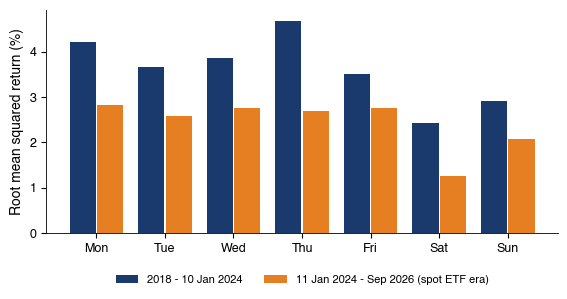

  Weekend / weekday variance ratio, before the spot ETFs  0.449
  Weekend / weekday variance ratio, since the spot ETFs   0.395
  Weekday standard deviation before the ETFs (%)          4.007
  Weekend standard deviation before the ETFs (%)          2.685
  Weekday standard deviation since the ETFs (%)           2.727
  Weekend standard deviation since the ETFs (%)           1.711


In [7]:
def fig_weekday(start='2018-01-01'):
    """Variance of Bitcoin returns by day of the week, before and after the launch of the spot ETFs."""
    r = 100 * log_returns('BTC', start)
    pre, post = r.loc[:'2024-01-10'], r.loc[ETF_START:]
    days = ['Mon', 'Tue', 'Wed', 'Thu', 'Fri', 'Sat', 'Sun']
    v_pre = pre.groupby(pre.index.dayofweek).apply(lambda x: np.sqrt((x ** 2).mean()))
    v_post = post.groupby(post.index.dayofweek).apply(lambda x: np.sqrt((x ** 2).mean()))
    fig, ax = plt.subplots(figsize=(6.6, 2.9))
    x = np.arange(7)
    ax.bar(x - 0.2, v_pre.values, 0.38, color=MainBlue, label='2018 - 10 Jan 2024')
    ax.bar(x + 0.2, v_post.values, 0.38, color=Orange, label='11 Jan 2024 - Sep 2026 (spot ETF era)')
    ax.set_xticks(x)
    ax.set_xticklabels(days)
    ax.set_ylabel('Root mean squared return (%)')
    legend_outside_bottom(ax, ncol=2, y=-0.14)
    save_fig('ch16_weekday')

    def ratio(x):
        """Ratio of (centred) variances: weekend / weekdays."""
        we = x[x.index.dayofweek >= 5]
        wd = x[x.index.dayofweek < 5]
        return we.var(ddof=1) / wd.var(ddof=1)
    return dict(ratio_pre=ratio(pre), ratio_post=ratio(post), pre=v_pre.tolist(), post=v_post.tolist(),
                wd_pre=np.sqrt((pre[pre.index.dayofweek < 5] ** 2).mean()),
                we_pre=np.sqrt((pre[pre.index.dayofweek >= 5] ** 2).mean()),
                wd_post=np.sqrt((post[post.index.dayofweek < 5] ** 2).mean()),
                we_post=np.sqrt((post[post.index.dayofweek >= 5] ** 2).mean()))


show(fig_weekday(), {'ratio_pre': 'Weekend / weekday variance ratio, before the spot ETFs',
 'ratio_post': 'Weekend / weekday variance ratio, since the spot ETFs',
 'wd_pre': 'Weekday standard deviation before the ETFs (%)',
 'we_pre': 'Weekend standard deviation before the ETFs (%)',
 'wd_post': 'Weekday standard deviation since the ETFs (%)',
 'we_post': 'Weekend standard deviation since the ETFs (%)'})

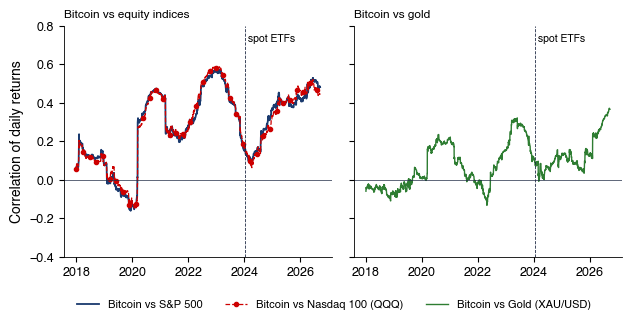

  Bitcoin vs S&P 500: correlation 2017-2019                         0.023
  Bitcoin vs S&P 500: correlation 2020-2023                         0.392
  Bitcoin vs S&P 500: correlation since the spot ETFs               0.384
  Bitcoin vs S&P 500: latest 250-day correlation                    0.480
  Bitcoin vs Nasdaq 100 ETF (QQQ): correlation 2017-2019            0.027
  Bitcoin vs Nasdaq 100 ETF (QQQ): correlation 2020-2023            0.402
  Bitcoin vs Nasdaq 100 ETF (QQQ): correlation since the spot ETFs  0.379
  Bitcoin vs Nasdaq 100 ETF (QQQ): latest 250-day correlation       0.445
  Bitcoin vs gold: correlation 2017-2019                            -0.020
  Bitcoin vs gold: correlation 2020-2023                            0.122
  Bitcoin vs gold: correlation since the spot ETFs                  0.218
  Bitcoin vs gold: latest 250-day correlation                       0.366


In [8]:
def fig_rolling_corr():
    """Correlation over 250 common days: Bitcoin with the S&P 500, the Nasdaq 100 and gold (prices aligned first).
    Left panel: the equity indices (almost overlapping: solid line vs dashed line with markers); right: gold."""
    fig, axes = plt.subplots(1, 2, figsize=(7.2, 3.0), sharex=True, sharey=True,
                             gridspec_kw=dict(wspace=0.08))
    out = {}
    style = {'SPX': (axes[0], MainBlue, '-', None, 1.3), 'QQQ': (axes[0], IDAred, '--', 'o', 0.9),
             'GOLD': (axes[1], Forest, '-', None, 1.0)}
    for k in ['SPX', 'QQQ', 'GOLD']:
        ax, c, ls, mk, lw = style[k]
        r = joint_returns(['BTC', k], '2016-01-01')
        rc = r['BTC'].rolling(250).corr(r[k]).loc['2018-01-01':]
        ax.plot(rc.index, rc.values, color=c, lw=lw, ls=ls, marker=mk, markevery=60, markersize=3,
                label=f'Bitcoin vs {LABELS[k]}')
        per = {}
        for lab, a, b in [('p1', '2017-01-01', '2019-12-31'), ('p2', '2020-01-01', '2023-12-31'),
                          ('p3', ETF_START, END)]:
            x = r.loc[a:b]
            per[lab] = x['BTC'].corr(x[k])
            per[lab + '_n'] = len(x)
        out[k] = dict(per, last=rc.iloc[-1], max=rc.max(), max_date=str(rc.idxmax().date()))
    for ax, ttl in zip(axes, ['Bitcoin vs equity indices', 'Bitcoin vs gold']):
        ax.axhline(0, color=Gray, lw=0.5)
        ax.axvline(pd.Timestamp(ETF_START), color=Gray, lw=0.6, ls='--')
        ax.set_title(ttl, fontsize=8.5, loc='left', color='black')
    for ax in axes:
        ax.text(pd.Timestamp(ETF_START), 0.72, ' spot ETFs', fontsize=7.5, color='black')
        ax.xaxis.set_major_locator(mdates.YearLocator(2))
        ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
    axes[0].set_ylim(-0.4, 0.8)
    axes[0].set_ylabel('Correlation of daily returns')
    fig_legend_bottom(fig, ncol=3, y=0.0)
    save_fig('ch16_rolling_corr')
    return out


show(fig_rolling_corr(), {'SPX/p1': 'Bitcoin vs S&P 500: correlation 2017-2019',
 'SPX/p2': 'Bitcoin vs S&P 500: correlation 2020-2023',
 'SPX/p3': 'Bitcoin vs S&P 500: correlation since the spot ETFs',
 'SPX/last': 'Bitcoin vs S&P 500: latest 250-day correlation',
 'QQQ/p1': 'Bitcoin vs Nasdaq 100 ETF (QQQ): correlation 2017-2019',
 'QQQ/p2': 'Bitcoin vs Nasdaq 100 ETF (QQQ): correlation 2020-2023',
 'QQQ/p3': 'Bitcoin vs Nasdaq 100 ETF (QQQ): correlation since the spot ETFs',
 'QQQ/last': 'Bitcoin vs Nasdaq 100 ETF (QQQ): latest 250-day correlation',
 'GOLD/p1': 'Bitcoin vs gold: correlation 2017-2019',
 'GOLD/p2': 'Bitcoin vs gold: correlation 2020-2023',
 'GOLD/p3': 'Bitcoin vs gold: correlation since the spot ETFs',
 'GOLD/last': 'Bitcoin vs gold: latest 250-day correlation'})

## 4. Crypto indices and the CRIX rule

- Laspeyres-type index (quantities fixed within the period) with monthly reallocation and a divisor; top-$k$ indices and tracking error.
- CRIX rule of Trimborn & Härdle (2018): free weights for added coins, Epanechnikov kernel likelihood, Akaike information criterion $\mathrm{AIC} = -2\log L + 2s$, quarterly review, ECRIX (stop at the first rise of the AIC) and EFCRIX (global minimum) stopping rules.

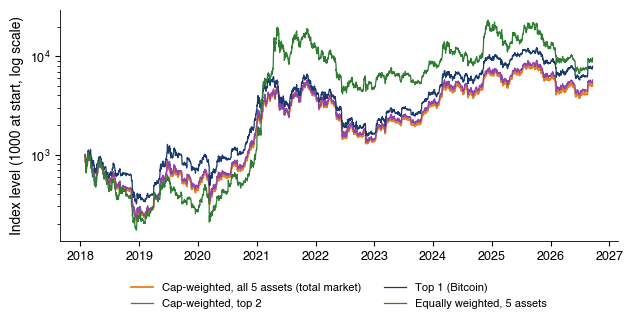

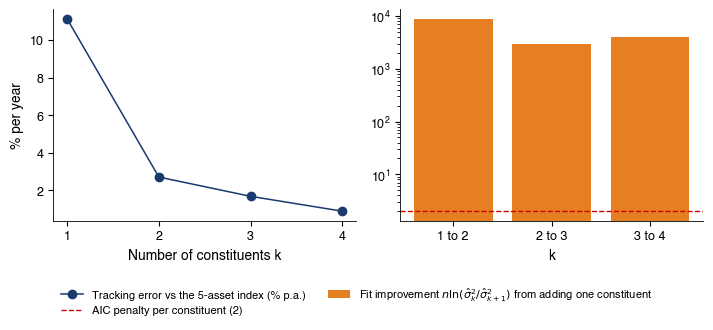

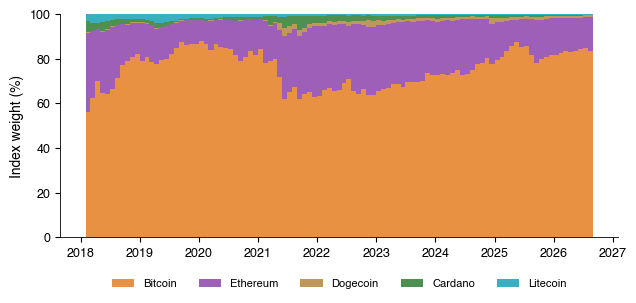

                  AIC(k)  Tracking error vs the total index (% a year)
Constituents k                                                        
1              -32436.60                                         11.13
2              -41329.45                                          2.71
3              -44320.55                                          1.69
4              -48299.39                                          0.90
  Constituents chosen by the AIC                  4
  Total index: compound annual growth (%)         21.36
  Total index: volatility (% a year)              65.72
  Equal-weight index: compound annual growth (%)  30.02
  Equal-weight index: volatility (% a year)       82.46


In [9]:
def crix_index(k=None, weighting='cap', mv=None, px=None):
    """Laspeyres index with monthly reweighting: the first k constituents by market value at the end of the previous
    month; quantities are fixed within the month and the divisor keeps the index continuous at reweighting."""
    if mv is None:
        mv = market_values()
    if px is None:
        px = pd.concat([price(a) for a in CRIX_UNIVERSE], axis=1).reindex(mv.index)
    months = mv.index.to_period('M')
    level = pd.Series(np.nan, index=mv.index)
    wts = {}
    val = 1000.0
    first = True
    for per in months.unique():
        idx = mv.index[months == per]
        prev = mv.loc[:idx[0] - pd.Timedelta(days=1)]
        if prev.empty:
            continue
        base = prev.iloc[-1]
        members = base.sort_values(ascending=False).index[:(k or len(base))]
        w = base[members] / base[members].sum() if weighting == 'cap' else pd.Series(1 / len(members), index=members)
        p0 = px.loc[prev.index[-1], members]
        rel = (px.loc[idx, members] / p0).mul(w, axis=1).sum(axis=1)
        if first:
            level.loc[prev.index[-1]] = val
            first = False
        level.loc[idx] = val * rel
        val = level.loc[idx[-1]]
        wts[str(per)] = w.reindex(CRIX_UNIVERSE).fillna(0)
    return level.dropna(), pd.DataFrame(wts).T


def crix_aic(mv=None, px=None):
    """AIC(k) = n ln(s2_k) + 2k, with s2_k the mean squared difference between the log returns of the total index
    (all 7 constituents) and of the index with k constituents; over the full period and for each year."""
    if mv is None:
        mv = market_values()
    if px is None:
        px = pd.concat([price(a) for a in CRIX_UNIVERSE], axis=1).reindex(mv.index)
    tot, _ = crix_index(None, 'cap', mv, px)
    rt = np.log(tot).diff().dropna()
    res = {}
    te = {}
    for k in range(1, len(CRIX_UNIVERSE)):
        lk, _ = crix_index(k, 'cap', mv, px)
        d = (np.log(lk).diff() - np.log(tot).diff()).dropna()
        res[k] = d
        te[k] = 100 * d.std() * np.sqrt(365)
    n = len(rt)
    aic = {k: n * np.log((d ** 2).mean()) + 2 * k for k, d in res.items()}
    bic = {k: n * np.log((d ** 2).mean()) + k * np.log(n) for k, d in res.items()}
    yearly = {}
    for y in sorted(set(rt.index.year)):
        a = {k: len(d.loc[str(y)]) * np.log((d.loc[str(y)] ** 2).mean()) + 2 * k for k, d in res.items()}
        yearly[y] = min(a, key=a.get)
    return dict(aic=aic, bic=bic, te=te, k_aic=min(aic, key=aic.get), k_bic=min(bic, key=bic.get), n=n,
                yearly=yearly)


def fig_crix():
    """Total index (7 assets), Bitcoin alone (k = 1), the equal-weight index; AIC(k) and the weights over time."""
    mv = market_values()
    px = pd.concat([price(a) for a in CRIX_UNIVERSE], axis=1).reindex(mv.index)
    tot, w = crix_index(None, 'cap', mv, px)
    k1, _ = crix_index(1, 'cap', mv, px)
    k2, _ = crix_index(2, 'cap', mv, px)
    ew, _ = crix_index(None, 'equal', mv, px)
    a = crix_aic(mv, px)
    # the index
    fig, ax = plt.subplots(figsize=(7.2, 3.0))
    for s, lab, c, lw in [(tot, f'Cap-weighted, all {len(CRIX_UNIVERSE)} assets (total market)', Orange, 1.3), (k2, 'Cap-weighted, top 2', Purple, 0.9),
                          (k1, 'Top 1 (Bitcoin)', MainBlue, 0.9), (ew, f'Equally weighted, {len(CRIX_UNIVERSE)} assets', Forest, 0.9)]:
        ax.plot(s.index, s.values, color=c, lw=lw, label=lab)
    ax.set_yscale('log')
    ax.set_ylabel('Index level (1000 at start, log scale)')
    legend_outside_bottom(ax, ncol=2, y=-0.14)
    save_fig('ch16_crix_index')
    # tracking error and AIC gain when each constituent is added
    fig, axes = plt.subplots(1, 2, figsize=(7.2, 2.8))
    ks = list(a['te'])
    axes[0].plot(ks, [a['te'][k] for k in ks], 'o-', color=MainBlue, label=f'Tracking error vs the {len(CRIX_UNIVERSE)}-asset index (% p.a.)')
    axes[0].set_xlabel('Number of constituents k')
    axes[0].set_ylabel('% per year')
    axes[0].set_xticks(ks)
    # fit improvement n ln(s2_k / s2_(k+1)) = AIC(k) - AIC(k+1) + 2, compared with the penalty 2
    fit = [a['aic'][k] - a['aic'][k + 1] + 2 for k in ks[:-1]]
    axes[1].bar([f'{k} to {k + 1}' for k in ks[:-1]], fit, color=Orange,
                label='Fit improvement $n\\ln(\\hat\\sigma^2_k/\\hat\\sigma^2_{k+1})$ from adding one constituent')
    axes[1].axhline(2, color=IDAred, lw=1.0, ls='--', label='AIC penalty per constituent (2)')
    axes[1].set_yscale('log')
    axes[1].set_xlabel('k')
    fig.tight_layout()
    fig_legend_bottom(fig, ncol=2, y=0.0)
    save_fig('ch16_crix_aic')
    # the weights
    fig, ax = plt.subplots(figsize=(7.2, 2.9))
    wi = w.copy()
    wi.index = pd.PeriodIndex(wi.index, freq='M').to_timestamp()
    ax.stackplot(wi.index, [100 * wi[c] for c in CRIX_UNIVERSE], labels=[LABELS[c] for c in CRIX_UNIVERSE],
                 colors=[COL[c] for c in CRIX_UNIVERSE], alpha=0.85, lw=0, step='post')
    ax.set_ylim(0, 100)
    ax.set_ylabel('Index weight (%)')
    legend_outside_bottom(ax, ncol=5, y=-0.14)
    save_fig('ch16_crix_weights')
    rt = np.log(tot).diff().dropna()
    re_ = np.log(ew).diff().dropna()
    yrs = (tot.index[-1] - tot.index[0]).days / 365.25
    return dict(aic={str(k): v for k, v in a['aic'].items()}, te={str(k): v for k, v in a['te'].items()},
                k_aic=a['k_aic'], k_bic=a['k_bic'], n=a['n'], yearly={str(k): v for k, v in a['yearly'].items()},
                gain={str(k): a['aic'][k] - a['aic'][k + 1] for k in list(a['aic'])[:-1]},
                tot_end=tot.iloc[-1], k1_end=k1.iloc[-1], k2_end=k2.iloc[-1], ew_end=ew.iloc[-1],
                tot_cagr=100 * ((tot.iloc[-1] / 1000) ** (1 / yrs) - 1), ew_cagr=100 * ((ew.iloc[-1] / 1000) ** (1 / yrs) - 1),
                tot_vol=100 * rt.std() * np.sqrt(365), ew_vol=100 * re_.std() * np.sqrt(365),
                w_btc_mean=100 * w['BTC'].mean(), w_btc_min=100 * w['BTC'].min(), w_btc_max=100 * w['BTC'].max(),
                w_last={c: 100 * w[c].iloc[-1] for c in CRIX_UNIVERSE}, start=str(tot.index[0].date()), years=yrs,
                ew_year={str(d.year): 100 * v for d, v in ew.resample('YE').last().pct_change().dropna().items()},
                tot_year={str(d.year): 100 * v for d, v in tot.resample('YE').last().pct_change().dropna().items()},
                k1_year={str(d.year): 100 * v for d, v in k1.resample('YE').last().pct_change().dropna().items()})


cx = fig_crix()
print(pd.DataFrame({'AIC(k)': cx['aic'], 'Tracking error vs the total index (% a year)': cx['te']}).rename_axis('Constituents k').round(2))
show(cx, {'k_aic': 'Constituents chosen by the AIC',
 'tot_cagr': 'Total index: compound annual growth (%)',
 'tot_vol': 'Total index: volatility (% a year)',
 'ew_cagr': 'Equal-weight index: compound annual growth (%)',
 'ew_vol': 'Equal-weight index: volatility (% a year)'}, digits=2)

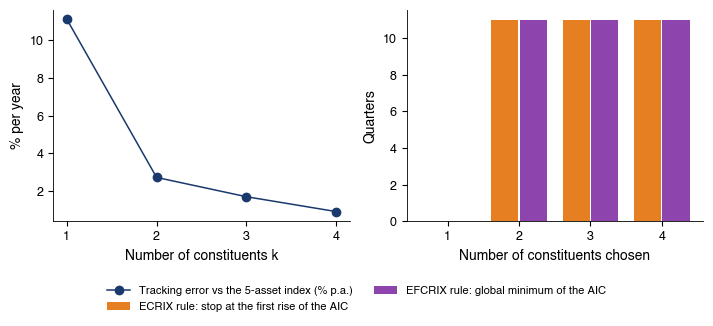

Number of quarters in which each rule chooses k constituents


,ECRIX,EFCRIX
Constituents k,,
1,0,0
2,11,11
3,11,11
4,11,11


In [10]:
from scipy.optimize import least_squares, brentq


def sj_bandwidth(x):
    """Sheather-Jones plug-in bandwidth ('solve-the-equation') for the Gaussian kernel (as bw.SJ in R),
    converted to the Epanechnikov kernel with variance 1 (factor (R(K_E)/R(K_G))^(1/5))."""
    x = np.asarray(x, float)
    n = len(x)
    d = (x[:, None] - x[None, :]).ravel()
    phi = lambda u: np.exp(-u ** 2 / 2) / np.sqrt(2 * np.pi)
    psi4 = lambda h: np.sum(((d / h) ** 4 - 6 * (d / h) ** 2 + 3) * phi(d / h)) / (n * (n - 1) * h ** 5)
    psi6 = lambda h: np.sum(((d / h) ** 6 - 15 * (d / h) ** 4 + 45 * (d / h) ** 2 - 15) * phi(d / h)) / (n * (n - 1) * h ** 7)
    scale = min(np.std(x, ddof=1), stats.iqr(x) / 1.349)
    a = 1.24 * scale * n ** (-1 / 7)
    b = 1.23 * scale * n ** (-1 / 9)
    c1 = 1 / (2 * np.sqrt(np.pi) * n)
    td = -psi6(b)
    alph2 = 1.357 * (psi4(a) / td) ** (1 / 7)
    f = lambda h: (c1 / psi4(alph2 * h ** (5 / 7))) ** 0.2 - h
    lo, hi = 0.1 * scale * n ** (-0.2), 3 * scale * n ** (-0.2)
    try:
        hg = brentq(f, lo, hi)
    except ValueError:
        hg = 1.06 * scale * n ** (-0.2)
    return hg * ((3 / (5 * np.sqrt(5))) / (1 / (2 * np.sqrt(np.pi)))) ** 0.2


def epa_loglik(base, x):
    """Log-likelihood of the values x under the Epanechnikov kernel density (support +-sqrt(5)) of the base residuals."""
    h = sj_bandwidth(base)
    u = (x[:, None] - base[None, :]) / h
    k = 3 / (4 * np.sqrt(5)) * (1 - u ** 2 / 5) * (np.abs(u) <= np.sqrt(5))
    f = k.mean(axis=1) / h
    return float(np.sum(np.log(np.maximum(f, 1e-300)))), h


def crix_window(mv, px, days):
    """For the days of a quarterly window: log returns of the total index (all coins, weight 1)
    and, for each day, the quantities Q = market value / price at the end of the previous month, ordered by
    market value (the top-down approach, eq. 23)."""
    rows = []
    for t in days:
        prevm = mv.loc[:t.to_period('M').start_time - pd.Timedelta(days=1)]
        if prevm.empty:
            return None
        base = prevm.iloc[-1]
        order = base.sort_values(ascending=False).index.tolist()
        q = (base * 1e9 / px.loc[prevm.index[-1]])[order]
        i = px.index.get_loc(t)
        rows.append((order, q.values, px.iloc[i][order].values, px.iloc[i - 1][order].values))
    return rows


def crix_residuals(rows, k, beta):
    """eps_hat(k, beta) = total-index return - CRIX(k, beta) return, eqs. (11) and (22): the first
    constituent with weight 1, the next k - 1 with weights beta."""
    e = []
    for order, q, p1, p0 in rows:
        tot = np.log((p1 * q).sum() / (p0 * q).sum())
        w = np.concatenate([[1.0], beta, np.zeros(len(q) - k)])
        a1, a0 = (w * p1 * q).sum(), (w * p0 * q).sum()
        e.append(tot - np.log(a1 / a0) if a1 > 0 and a0 > 0 else 1.0)
    return np.array(e)


def crix_rule(kmax=4):
    """Number of constituents chosen each quarter (window: last three months) by ECRIX (stop at the first rise
    of the AIC) and EFCRIX (global minimum), with k1 = 1 and step s = 1 (Trimborn & Hardle, 2018, Sections 3-5)."""
    mv = market_values()
    px = pd.concat([price(a) for a in CRIX_UNIVERSE], axis=1).reindex(mv.index)
    qends = pd.date_range('2018-06-30', END, freq='QE')
    res = []
    for qe in qends:
        days = mv.loc[qe.to_period('Q').start_time:qe].index      # the calendar quarter ending at qe
        rows = crix_window(mv, px, days)
        if rows is None or len(rows) < 60:
            continue
        base = crix_residuals(rows, 1, np.array([]))
        ll0, h = epa_loglik(base, base)
        aic = {1: -2 * ll0}
        for k in range(2, kmax + 1):
            fit = least_squares(lambda b: crix_residuals(rows, k, b), np.ones(k - 1))
            ll, _ = epa_loglik(base, crix_residuals(rows, k, fit.x))
            aic[k] = -2 * ll + 2 * (k - 1)
        ek = kmax
        for k in range(2, kmax + 1):
            if aic[k] > aic[k - 1]:
                ek = k - 1
                break
        res.append(dict(q=str(qe.date()), n=len(rows), h=h, aic=aic, ecrix=ek, efcrix=min(aic, key=aic.get)))
    ec = pd.Series([r['ecrix'] for r in res])
    ef = pd.Series([r['efcrix'] for r in res])
    return dict(quarters=res, n_q=len(res), first=res[0]['q'], last=res[-1]['q'],
                ecrix_counts={str(k): int((ec == k).sum()) for k in range(1, kmax + 1)},
                efcrix_counts={str(k): int((ef == k).sum()) for k in range(1, kmax + 1)},
                ecrix_mode=int(ec.mode().iloc[0]), efcrix_mode=int(ef.mode().iloc[0]),
                ecrix_last=int(ec.iloc[-1]), efcrix_last=int(ef.iloc[-1]))


def fig_crix_rule(cr, te):
    """Left: tracking error of the index with the first k constituents; right: number of quarters in which
    the ECRIX and EFCRIX rules choose k constituents."""
    fig, axes = plt.subplots(1, 2, figsize=(7.2, 2.8))
    ks = [1, 2, 3, 4]
    axes[0].plot(ks, [te[str(k)] for k in ks], 'o-', color=MainBlue, label='Tracking error vs the 5-asset index (% p.a.)')
    axes[0].set_xlabel('Number of constituents k')
    axes[0].set_ylabel('% per year')
    axes[0].set_xticks(ks)
    x = np.arange(len(ks))
    axes[1].bar(x - 0.2, [cr['ecrix_counts'][str(k)] for k in ks], 0.38, color=Orange,
                label='ECRIX rule: stop at the first rise of the AIC')
    axes[1].bar(x + 0.2, [cr['efcrix_counts'][str(k)] for k in ks], 0.38, color=Purple,
                label='EFCRIX rule: global minimum of the AIC')
    axes[1].set_xticks(x)
    axes[1].set_xticklabels([str(k) for k in ks])
    axes[1].set_xlabel('Number of constituents chosen')
    axes[1].set_ylabel('Quarters')
    fig.tight_layout()
    fig_legend_bottom(fig, ncol=2, y=0.0)
    save_fig('ch16_crix_rule')


cr = crix_rule()
fig_crix_rule(cr, {str(k): v for k, v in cx['te'].items()})
print('Number of quarters in which each rule chooses k constituents')
pd.DataFrame({'ECRIX': cr['ecrix_counts'], 'EFCRIX': cr['efcrix_counts']}).rename_axis('Constituents k')

## 5. Stablecoins

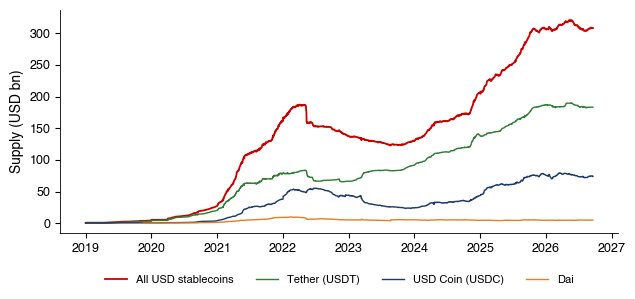

  USD stablecoin supply, end of sample (billion USD)     308.02
  USD stablecoin supply on 1 January 2020 (billion USD)  4.17
  Tether (billion USD)                                   183.33
  USD Coin (billion USD)                                 73.92
  Dai (billion USD)                                      4.77
  Tether share (%)                                       59.52
  USD Coin share (%)                                     24.00
  Number of USD stablecoins                              340
  Fiat-backed (billion USD)                              282.85
  Crypto-backed (billion USD)                            22.36
  Algorithmic (billion USD)                              0.15


In [11]:
def fig_stablecoin_supply():
    """Supply of USD stablecoins: total, USDT, USDC, DAI (billion USD)."""
    tot = stablecoin_chart()['value'].loc['2019-01-01':]
    parts = {'USDT': stablecoin_chart(1)['value'], 'USDC': stablecoin_chart(2)['value'], 'DAI': stablecoin_chart(5)['value']}
    fig, ax = plt.subplots(figsize=(7.2, 2.9))
    ax.plot(tot.index, tot.values, color=IDAred, lw=1.3, label='All USD stablecoins')
    for k, s in parts.items():
        s = s.loc['2019-01-01':]
        ax.plot(s.index, s.values, color=COL[k], lw=1.0, label=LABELS[k])
    ax.set_ylabel('Supply (USD bn)')
    legend_outside_bottom(ax, ncol=4, y=-0.14)
    save_fig('ch16_stablecoin_supply')
    # classification by mechanism on the same date as the total (END): the value of each coin above 100 million USD,
    # the other coins = the total minus their sum
    lst = stablecoin_list()
    lst = lst.assign(mechanism=lst['mechanism'].replace({'crytpo-backed': 'crypto-backed'}))
    big = lst[lst['supply'] >= 0.1].copy()
    vals = []
    for i in big['id']:
        v = stablecoin_chart(int(i))['value'].loc[:END].dropna()
        vals.append(float(v.iloc[-1]) if len(v) and v.index[-1] >= pd.Timestamp(END) - pd.Timedelta(days=3) else 0.0)
    big['value'] = vals
    big = big[big['value'] > 0].sort_values('value', ascending=False)
    mech = big.groupby('mechanism')['value'].sum()
    return dict(total_end=tot.iloc[-1], total_2020=tot.loc[:'2020-01-01'].iloc[-1],
                n_big=int(len(big)), other=float(tot.iloc[-1] - big['value'].sum()),
                usdt_end=parts['USDT'].iloc[-1], usdc_end=parts['USDC'].iloc[-1], dai_end=parts['DAI'].iloc[-1],
                usdt_share=100 * parts['USDT'].iloc[-1] / tot.iloc[-1], usdc_share=100 * parts['USDC'].iloc[-1] / tot.iloc[-1],
                usdc_peak=parts['USDC'].max(), usdc_peak_date=str(parts['USDC'].idxmax().date()),
                n_coins=int(len(lst)), mech={k: float(v) for k, v in mech.items()},
                top=[dict(symbol=r.symbol, name=r.name, mechanism=r.mechanism, supply=r.value) for r in big.head(12).itertuples()],
                end=str(tot.index[-1].date()),
                tot_peak22=tot.loc[:'2022-12-31'].max(), tot_peak22_date=str(tot.loc[:'2022-12-31'].idxmax().date()),
                tot_trough=tot.loc['2022-06-01':'2024-06-30'].min(),
                tot_trough_date=str(tot.loc['2022-06-01':'2024-06-30'].idxmin().date()),
                usdc_peak22=parts['USDC'].loc[:'2022-12-31'].max(),
                usdc_peak22_date=str(parts['USDC'].loc[:'2022-12-31'].idxmax().date()),
                usdc_trough=parts['USDC'].loc['2022-06-01':'2024-06-30'].min(),
                usdc_trough_date=str(parts['USDC'].loc['2022-06-01':'2024-06-30'].idxmin().date()))


ss = fig_stablecoin_supply()
show(ss, {'total_end': 'USD stablecoin supply, end of sample (billion USD)',
 'total_2020': 'USD stablecoin supply on 1 January 2020 (billion USD)',
 'usdt_end': 'Tether (billion USD)',
 'usdc_end': 'USD Coin (billion USD)',
 'dai_end': 'Dai (billion USD)',
 'usdt_share': 'Tether share (%)',
 'usdc_share': 'USD Coin share (%)',
 'n_coins': 'Number of USD stablecoins',
 'mech/fiat-backed': 'Fiat-backed (billion USD)',
 'mech/crypto-backed': 'Crypto-backed (billion USD)',
 'mech/algorithmic': 'Algorithmic (billion USD)'}, digits=2)

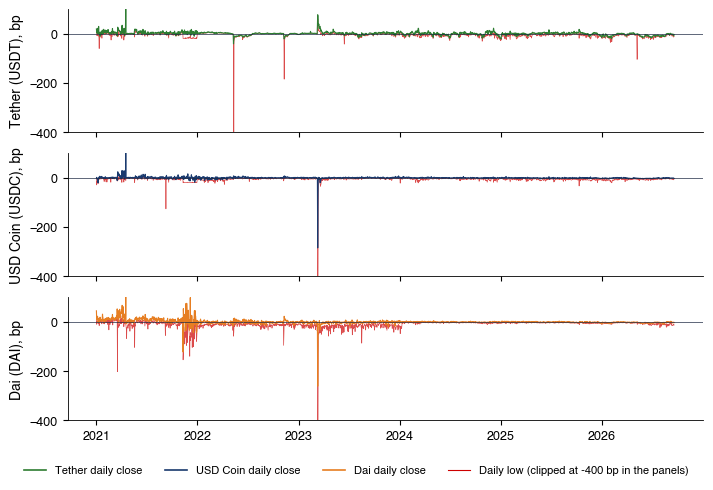

,Tether,USD Coin,Dai
Days,2087,2087,2087
Standard deviation of the close deviation (bp),7.29,7.48,10.83
Median absolute deviation (bp),3.08,1.13,2.21
Days with |deviation| above 50 bp (%),0.14,0.14,0.57
Days with |deviation| above 100 bp (%),0.05,0.1,0.14
Lowest daily low (bp),-515.14,-1226.0,-1029.97
Date of the lowest low,2022-05-12,2023-03-11,2023-03-11
Lowest close (bp),-41.28,-285.0,-261.31
Date of the lowest close,2022-05-11,2023-03-11,2023-03-11
AR(1) coefficient of the close deviation,0.73,0.29,0.33


In [12]:
def peg_stats(key, start='2021-01-01'):
    """Peg deviation (basis points) on closing prices and on daily lows."""
    d = read_market(ASSETS[key][0]).loc[start:END]
    dev = 1e4 * (d['close'] - 1)
    low = 1e4 * (d['low'] - 1)
    high = 1e4 * (d['high'] - 1)
    x = dev.values
    phi = np.corrcoef(x[1:], x[:-1])[0, 1]
    return dict(N=len(dev), sd=dev.std(), mad=np.median(np.abs(dev)), gt50=100 * (dev.abs() > 50).mean(),
                gt100=100 * (dev.abs() > 100).mean(), low_min=low.min(), low_min_date=str(low.idxmin().date()),
                high_max=high.max(), high_max_date=str(high.idxmax().date()), close_min=dev.min(),
                close_min_date=str(dev.idxmin().date()), phi=phi, half_life=np.log(0.5) / np.log(abs(phi)))


def fig_peg_deviation(start='2021-01-01'):
    """Daily deviation from 1 USD for USDT, USDC and DAI (close and daily low)."""
    PEG_NAME = {'USDT': 'Tether (USDT)', 'USDC': 'USD Coin (USDC)', 'DAI': 'Dai (DAI)'}
    fig, axes = plt.subplots(3, 1, figsize=(7.2, 4.6), sharex=True)
    out = {}
    for ax, k in zip(axes, STABLE):
        d = read_market(ASSETS[k][0]).loc[start:END]
        dev = 1e4 * (d['close'] - 1)
        low = 1e4 * (d['low'] - 1)
        ax.plot(low.index, low.clip(lower=-1500).values, color=IDAred, lw=0.5, alpha=0.7, label='Daily low')
        ax.plot(dev.index, dev.values, color=COL[k], lw=0.8, label=f'Daily close')
        ax.axhline(0, color=Gray, lw=0.5)
        ax.set_ylim(-400, 100)
        ax.set_ylabel(PEG_NAME[k] + ', bp')
        out[k] = peg_stats(k, start)
    h = [plt.Line2D([], [], color=COL[k], lw=1.2) for k in STABLE] + [plt.Line2D([], [], color=IDAred, lw=0.8)]
    fig.tight_layout()
    fig_legend_bottom(fig, h, ['Tether daily close', 'USD Coin daily close', 'Dai daily close',
                               'Daily low (clipped at -400 bp in the panels)'], ncol=4, y=0.0)
    save_fig('ch16_peg_deviation')
    return out


table(fig_peg_deviation(), {'N': 'Days',
 'sd': 'Standard deviation of the close deviation (bp)',
 'mad': 'Median absolute deviation (bp)',
 'gt50': 'Days with |deviation| above 50 bp (%)',
 'gt100': 'Days with |deviation| above 100 bp (%)',
 'low_min': 'Lowest daily low (bp)',
 'low_min_date': 'Date of the lowest low',
 'close_min': 'Lowest close (bp)',
 'close_min_date': 'Date of the lowest close',
 'phi': 'AR(1) coefficient of the close deviation',
 'half_life': 'Half-life (days)'}, {'USDT': 'Tether', 'USDC': 'USD Coin', 'DAI': 'Dai'}, digits=2)

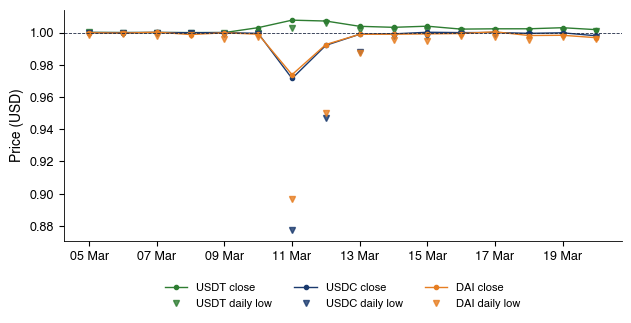

  USD Coin: lowest price (USD)        0.8774
  USD Coin: date of the lowest price  2023-03-11
  USD Coin: lowest close (USD)        0.9715
  Dai: lowest price (USD)             0.8970
  Dai: lowest close (USD)             0.9739
  Tether: highest price (USD)         1.0296


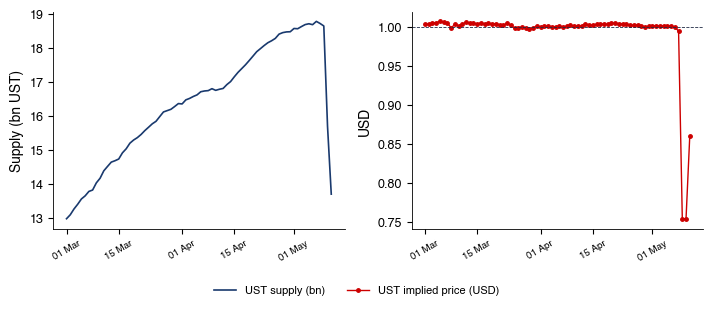

  TerraUSD supply at the peak (billion)  18.77
  Date of the peak                       2022-05-07
  TerraUSD supply, last day (billion)    13.69
  Last day                               2022-05-11
  Fall in supply from the peak (%)       27.05
  Lowest implied price (USD)             0.75
  Date of the lowest implied price       2022-05-10


In [13]:
def fig_depeg_2023():
    """March 2023: USDC and DAI below the peg after the closure of Silicon Valley Bank; USDT above the peg."""
    a, b = '2023-03-05', '2023-03-20'
    fig, ax = plt.subplots(figsize=(7.2, 3.0))
    out = {}
    for k in STABLE:
        d = read_market(ASSETS[k][0]).loc[a:b]
        ax.plot(d.index, d['close'], 'o-', color=COL[k], ms=3, lw=1.0, label=f'{k} close')
        ax.plot(d.index, d['low'], 'v', color=COL[k], ms=4, alpha=0.8, label=f'{k} daily low')
        out[k] = dict(low=d['low'].min(), low_date=str(d['low'].idxmin().date()), close_min=d['close'].min(),
                      high=d['high'].max(), close_max=d['close'].max())
    ax.axhline(1, color=Gray, lw=0.6, ls='--')
    ax.set_ylabel('Price (USD)')
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%d %b'))
    legend_outside_bottom(ax, ncol=3, y=-0.14)
    save_fig('ch16_depeg_2023')
    return out


def fig_ust():
    """TerraUSD (UST), April-May 2022: supply and implied price (value / supply), DefiLlama."""
    u = stablecoin_chart(3).loc['2022-03-01':'2022-05-31'].copy()
    u = u[u['supply'] > 0]
    u['px'] = u['value'] / u['supply']
    fig, axes = plt.subplots(1, 2, figsize=(7.2, 2.8))
    axes[0].plot(u.index, u['supply'], color=MainBlue, lw=1.2, label='UST supply (bn)')
    axes[0].set_ylabel('Supply (bn UST)')
    axes[1].plot(u.index, u['px'], 'o-', color=IDAred, ms=2.5, lw=1.0, label='UST implied price (USD)')
    axes[1].axhline(1, color=Gray, lw=0.6, ls='--')
    axes[1].set_ylabel('USD')
    for ax in axes:
        ax.xaxis.set_major_formatter(mdates.DateFormatter('%d %b'))
        ax.tick_params(axis='x', labelsize=7, rotation=30)
    fig.tight_layout()
    fig_legend_bottom(fig, ncol=2, y=0.0)
    save_fig('ch16_ust_collapse')
    last = u.index[-1]
    return dict(supply_peak=u['supply'].max(), supply_peak_date=str(u['supply'].idxmax().date()),
                supply_last=u['supply'].iloc[-1], last_date=str(last.date()), px_min=u['px'].min(),
                px_min_date=str(u['px'].idxmin().date()),
                drop_pct=100 * (1 - u['supply'].iloc[-1] / u['supply'].max()))


show(fig_depeg_2023(), {'USDC/low': 'USD Coin: lowest price (USD)',
 'USDC/low_date': 'USD Coin: date of the lowest price',
 'USDC/close_min': 'USD Coin: lowest close (USD)',
 'DAI/low': 'Dai: lowest price (USD)',
 'DAI/close_min': 'Dai: lowest close (USD)',
 'USDT/high': 'Tether: highest price (USD)'}, digits=4)
show(fig_ust(), {'supply_peak': 'TerraUSD supply at the peak (billion)',
 'supply_peak_date': 'Date of the peak',
 'supply_last': 'TerraUSD supply, last day (billion)',
 'last_date': 'Last day',
 'drop_pct': 'Fall in supply from the peak (%)',
 'px_min': 'Lowest implied price (USD)',
 'px_min_date': 'Date of the lowest implied price'}, digits=2)

## 6. DeFi and automated market makers

- Swap: $\Delta y = y\gamma\Delta x/(x + \gamma\Delta x)$; impermanent loss $2\sqrt{r}/(1 + r) - 1$; loss versus rebalancing (LVR) $\sigma^2/8$ against a portfolio that holds the pool's Ether each day (Milionis et al., 2022); the constant 50/50 mix has the same instantaneous rate.

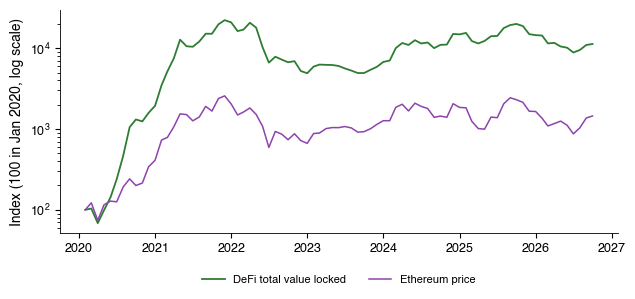

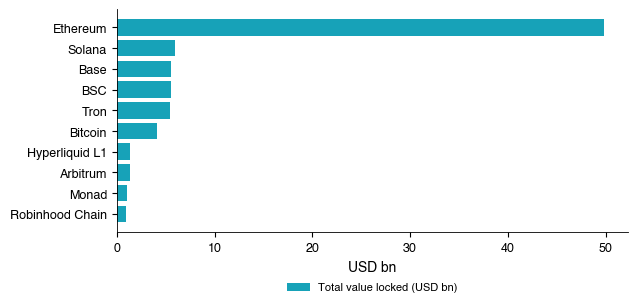

  Total value locked, peak (billion USD)           177.493
  Date of the peak                                 2021-11-09
  Total value locked, end of sample (billion USD)  88.126
  Months                                           80
  Beta of monthly TVL growth on the Ether return   0.789
  Newey-West standard error                        0.066
  R squared                                        0.620
  Ethereum share of TVL today (%)                  56.538


In [14]:
def fig_defi_tvl():
    """Total TVL (DefiLlama) and the Ethereum price, monthly, 2020-2026; TVL by blockchain today."""
    tvl = defi_tvl().loc['2020-01-01':]
    eth = price('ETH', '2020-01-01')
    m = pd.concat([tvl.resample('ME').last(), eth.resample('ME').last()], axis=1).dropna()
    m.columns = ['TVL', 'ETH']
    fig, ax = plt.subplots(figsize=(7.2, 2.9))
    ax.plot(m.index, 100 * m['TVL'] / m['TVL'].iloc[0], color=Forest, lw=1.3, label='DeFi total value locked')
    ax.plot(m.index, 100 * m['ETH'] / m['ETH'].iloc[0], color=Purple, lw=1.1, label='Ethereum price')
    ax.set_yscale('log')
    ax.set_ylabel('Index (100 in Jan 2020, log scale)')
    legend_outside_bottom(ax, ncol=2, y=-0.14)
    save_fig('ch16_defi_tvl')
    d = np.log(m).diff().dropna()
    reg = hac_ols(d['TVL'], d['ETH'], lags=3)
    # TVL by blockchain on the same date as the total series (END): the 10 largest of today's top 15
    ch = pd.Series({c: chain_tvl_at(c, END) for c in chain_tvl().head(15).index}).sort_values(ascending=False).head(10)
    fig, ax = plt.subplots(figsize=(6.6, 2.9))
    ax.barh(ch.index[::-1], ch.values[::-1], color=Teal, label='Total value locked (USD bn)')
    ax.set_xlabel('USD bn')
    legend_outside_bottom(ax, ncol=1, y=-0.18)
    save_fig('ch16_tvl_chains')
    tot_now = tvl.iloc[-1]
    return dict(peak=tvl.max(), peak_date=str(tvl.idxmax().date()), last=tvl.iloc[-1], last_date=str(tvl.index[-1].date()),
                start=tvl.iloc[0], beta=reg.params['ETH'], se=reg.bse['ETH'], r2=reg.rsquared, n=len(d),
                corr=d['TVL'].corr(d['ETH']), chains={k: float(v) for k, v in ch.items()},
                eth_share=100 * ch.iloc[0] / tot_now, chains_total=tot_now)


show(fig_defi_tvl(), {'peak': 'Total value locked, peak (billion USD)',
 'peak_date': 'Date of the peak',
 'last': 'Total value locked, end of sample (billion USD)',
 'n': 'Months',
 'beta': 'Beta of monthly TVL growth on the Ether return',
 'se': 'Newey-West standard error',
 'r2': 'R squared',
 'eth_share': 'Ethereum share of TVL today (%)'})

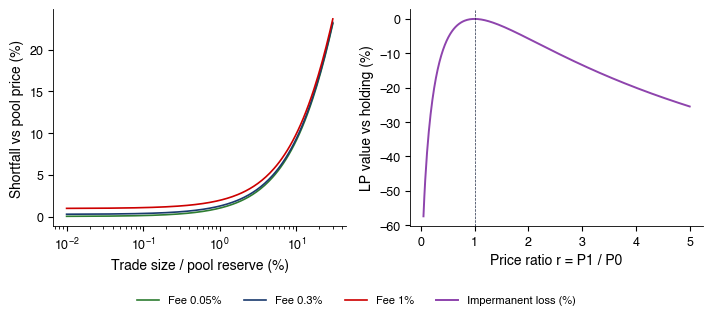

Loss relative to the pool price (%), by trade size (share of the pool reserve) and fee
            fee 0.05%  fee 0.3%  fee 1%
trade size                             
0.001           0.150     0.399   1.098
0.01            1.039     1.284   1.970
0.05            4.807     5.034   5.669
0.1             9.132     9.339   9.918
Impermanent loss (%) by price ratio r = P1/P0
r
0.25   -20.000
0.5     -5.719
0.8     -0.619
1.25    -0.619
2       -5.719
4      -20.000


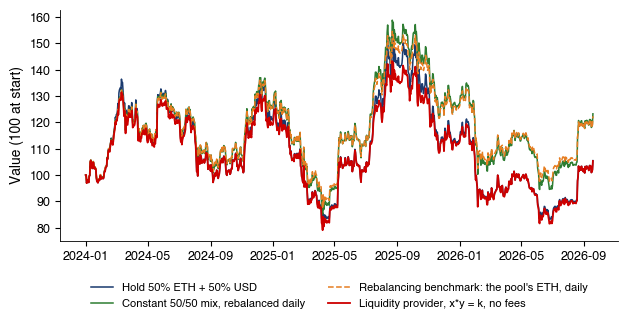

  Holding the assets: final value (start = 100)         105.506
  Liquidity provider: final value                       105.362
  Rebalancing benchmark (Milionis et al.): final value  122.353
  50/50 portfolio rebalanced daily: final value         123.271
  Impermanent loss at the end (%)                       -0.136
  Ether volatility (% a year)                           68.059
  LVR rate sigma^2/8 (% a year)                         5.790
  Realised LVR rate (% a year)                          5.827
  Log-growth gap, 50/50 mix over the pool (% a year)    5.786
  Fee income needed to match holding (% a year)         0.050


In [15]:
def amm_swap(x, y, dx, fee=0.003):
    """Swap dx of asset X in a pool x*y = k with a fee: amount received and effective price."""
    g = 1 - fee
    dy = y * g * dx / (x + g * dx)
    return dy, dy / dx


def impermanent_loss(r):
    """Impermanent loss of a 50/50 liquidity provider in x*y = k, for the price ratio r = P1/P0."""
    return 2 * np.sqrt(r) / (1 + r) - 1


def fig_amm_theory():
    """Price slippage by order size, and impermanent loss."""
    delta = np.logspace(-4, np.log10(0.3), 200)
    fig, axes = plt.subplots(1, 2, figsize=(7.2, 2.9))
    out = {}
    for fee, c in [(0.0005, Forest), (0.003, MainBlue), (0.01, IDAred)]:
        g = 1 - fee
        slip = 100 * (1 - g / (1 + g * delta))
        axes[0].plot(100 * delta, slip, color=c, lw=1.2, label=f'Fee {100 * fee:g}%')
        out[f'fee{fee}'] = {f'{d:g}': float(100 * (1 - g / (1 + g * d))) for d in [0.001, 0.01, 0.05, 0.1]}
    axes[0].set_xscale('log')
    axes[0].set_xlabel('Trade size / pool reserve (%)')
    axes[0].set_ylabel('Shortfall vs pool price (%)')
    rr = np.linspace(0.05, 5, 300)
    axes[1].plot(rr, 100 * impermanent_loss(rr), color=Purple, lw=1.4, label='Impermanent loss (%)')
    axes[1].axvline(1, color=Gray, lw=0.5, ls='--')
    axes[1].set_xlabel('Price ratio r = P1 / P0')
    axes[1].set_ylabel('LP value vs holding (%)')
    fig.tight_layout()
    fig_legend_bottom(fig, ncol=4, y=0.0)
    save_fig('ch16_amm_theory')
    out['il'] = {f'{r:g}': float(100 * impermanent_loss(r)) for r in [0.25, 0.5, 0.8, 1.25, 2, 4]}
    return out


def fig_lp_vs_hodl(start='2024-01-01'):
    """ETH/USD pool x*y = k without fees: the liquidity provider vs holding the assets, vs the rebalancing
    portfolio of Milionis et al. (2022) (holds the pool's ETH every day, x = V/(2P), and trades at the market price)
    and vs a 50/50 portfolio rebalanced daily (constant weight)."""
    p = price('ETH', start)
    rel = p / p.iloc[0]
    hodl = 100 * (1 + rel) / 2
    lp = 100 * np.sqrt(rel)
    R = p.pct_change().fillna(0)
    reb = 100 * (1 + 0.5 * R).cumprod()
    x_pool = lp / (2 * p)                                         # ETH held by the pool (V'(P) = V / 2P)
    dR = (x_pool.shift(1) * p.diff()).fillna(0)
    mmrz = 100 + dR.cumsum()                                      # R_t = R_(t-1) + x(P_(t-1)) (P_t - P_(t-1))
    fig, ax = plt.subplots(figsize=(7.2, 3.0))
    ax.plot(hodl.index, hodl.values, color=MainBlue, lw=1.1, label='Hold 50% ETH + 50% USD')
    ax.plot(reb.index, reb.values, color=Forest, lw=1.1, label='Constant 50/50 mix, rebalanced daily')
    ax.plot(mmrz.index, mmrz.values, color=Orange, lw=1.1, ls='--', label="Rebalancing benchmark: the pool's ETH, daily")
    ax.plot(lp.index, lp.values, color=IDAred, lw=1.3, label='Liquidity provider, x*y = k, no fees')
    ax.set_ylabel('Value (100 at start)')
    legend_outside_bottom(ax, ncol=2, y=-0.14)
    save_fig('ch16_lp_vs_hodl')
    r = np.log(p).diff().dropna()
    sig2 = r.var() * 365
    yrs = (p.index[-1] - p.index[0]).days / 365.25
    # realised LVR (Milionis et al., 2022): sum of the daily losses (dR_t - dV_t) / V_(t-1), annualised
    lvr_real = ((dR - lp.diff()) / lp.shift(1)).dropna().sum() / yrs
    return dict(start=str(p.index[0].date()), p0=p.iloc[0], p1=p.iloc[-1], ratio=rel.iloc[-1], hodl=hodl.iloc[-1],
                lp=lp.iloc[-1], reb=reb.iloc[-1], mmrz=mmrz.iloc[-1], lvr_level=mmrz.iloc[-1] - lp.iloc[-1],
                il=100 * (lp.iloc[-1] / hodl.iloc[-1] - 1), sigma=100 * np.sqrt(sig2),
                lvr_theory=100 * sig2 / 8, lvr_real=100 * lvr_real, cm_gap=100 * np.log(reb.iloc[-1] / lp.iloc[-1]) / yrs,
                years=yrs, fee_apr_hodl=100 * np.log(hodl.iloc[-1] / lp.iloc[-1]) / yrs)


am = fig_amm_theory()
print('Loss relative to the pool price (%), by trade size (share of the pool reserve) and fee')
print(pd.DataFrame({f'fee {100 * float(k[3:]):g}%': v for k, v in am.items() if k.startswith('fee')}).rename_axis('trade size').round(3))
print('Impermanent loss (%) by price ratio r = P1/P0')
print(pd.Series(am['il']).rename_axis('r').round(3).to_string())
show(fig_lp_vs_hodl(), {'hodl': 'Holding the assets: final value (start = 100)',
 'lp': 'Liquidity provider: final value',
 'mmrz': 'Rebalancing benchmark (Milionis et al.): final value',
 'reb': '50/50 portfolio rebalanced daily: final value',
 'il': 'Impermanent loss at the end (%)',
 'sigma': 'Ether volatility (% a year)',
 'lvr_theory': 'LVR rate sigma^2/8 (% a year)',
 'lvr_real': 'Realised LVR rate (% a year)',
 'cm_gap': 'Log-growth gap, 50/50 mix over the pool (% a year)',
 'fee_apr_hodl': 'Fee income needed to match holding (% a year)'})

## 7. Spot ETFs and crypto equities

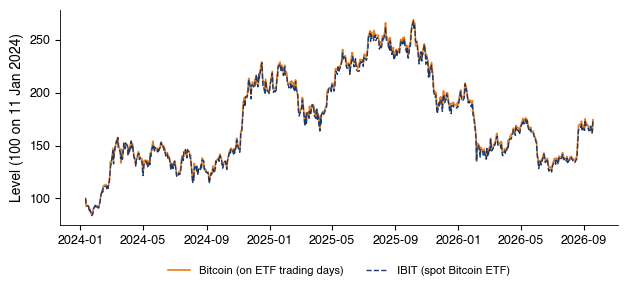

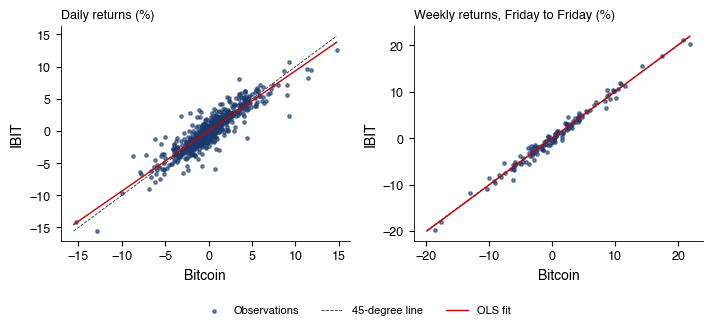

,IBIT vs Bitcoin,ETHA vs Ether
Common trading days,673.000,541.000
Weeks,140.000,112.000
Daily beta,0.935,0.938
Daily R squared,0.825,0.826
Daily beta on the next-day coin return,0.037,0.012
Weekly beta,1.007,0.986
Weekly beta: standard error,0.011,0.017
Weekly R squared,0.982,0.981
"Tracking error, daily (% a year)",20.806,29.889
"Tracking error, weekly (% a year)",6.190,8.951


In [16]:
def etf_tracking(etf='IBIT', coin='BTC'):
    """ETF vs underlying returns on the ETF's trading days: daily (same date and next date) and weekly (Friday);
    tracking error; drift of the ETF / underlying ratio (the annual fee)."""
    p = joint_prices([etf, coin])
    r = np.log(p).diff().dropna()
    c_next = np.log(price(coin)).diff().shift(-1).reindex(r.index)
    d_same = hac_ols(r[etf], r[coin])
    xx = pd.concat([r[coin], c_next.rename('next')], axis=1).dropna()
    d_two = hac_ols(r[etf].reindex(xx.index), xx)
    w = joint_returns([etf, coin], freq='W')
    wk = hac_ols(w[etf], w[coin])
    te_d = 100 * (r[etf] - r[coin]).std() * np.sqrt(252)
    te_w = 100 * (w[etf] - w[coin]).std() * np.sqrt(52)
    lr = np.log(p[etf] / p[coin])
    t = (lr.index - lr.index[0]).days / 365.25
    drift = np.polyfit(t, lr.values, 1)[0]
    vol = read_market(ASSETS[etf][0])
    dv = (vol['close'] * vol['volume']).loc[:END] / 1e9
    return dict(start=str(p.index[0].date()), n_d=len(r), n_w=len(w), beta_d=d_same.params[coin], r2_d=d_same.rsquared,
                beta_d_next=d_two.params['next'], beta_d_same=d_two.params[coin], r2_d_two=d_two.rsquared,
                beta_w=wk.params[coin], se_w=wk.bse[coin], r2_w=wk.rsquared, te_d=te_d, te_w=te_w,
                drift=100 * drift, corr_next=r[etf].corr(c_next), dv_mean=dv.mean(), dv_last60=dv.iloc[-60:].mean(),
                dv_max=dv.max(), dv_max_date=str(dv.idxmax().date()))


def fig_etf():
    """IBIT and Bitcoin: normalised levels and daily vs weekly returns."""
    p = joint_prices(['IBIT', 'BTC'])
    n = 100 * p / p.iloc[0]
    fig, ax = plt.subplots(figsize=(7.2, 2.8))
    ax.plot(n.index, n['BTC'], color=Orange, lw=1.2, label='Bitcoin (on ETF trading days)')
    ax.plot(n.index, n['IBIT'], color=MainBlue, lw=1.0, ls='--', label='IBIT (spot Bitcoin ETF)')
    ax.set_ylabel('Level (100 on 11 Jan 2024)')
    legend_outside_bottom(ax, ncol=2, y=-0.14)
    save_fig('ch16_etf_tracking')
    r = np.log(p).diff().dropna() * 100
    w = joint_returns(['IBIT', 'BTC'], freq='W') * 100
    fig, axes = plt.subplots(1, 2, figsize=(7.2, 3.0))
    for ax, x, lab in [(axes[0], r, 'Daily returns (%)'), (axes[1], w, 'Weekly returns, Friday to Friday (%)')]:
        ax.scatter(x['BTC'], x['IBIT'], s=6, color=MainBlue, alpha=0.6, label='Observations')
        lim = [min(x.min()), max(x.max())]
        ax.plot(lim, lim, color=Gray, lw=0.6, ls='--', label='45-degree line')
        b = np.polyfit(x['BTC'], x['IBIT'], 1)
        ax.plot(lim, np.polyval(b, lim), color=IDAred, lw=1.0, label='OLS fit')
        ax.set_xlabel('Bitcoin')
        ax.set_ylabel('IBIT')
        ax.set_title(lab, fontsize=9, loc='left')
    fig.tight_layout()
    fig_legend_bottom(fig, ncol=3, y=0.0)
    save_fig('ch16_etf_timing')
    return dict(ibit=etf_tracking('IBIT', 'BTC'), etha=etf_tracking('ETHA', 'ETH'),
                ibit_end=n['IBIT'].iloc[-1], btc_end=n['BTC'].iloc[-1])


etf = fig_etf()
table({k: etf[k] for k in ['ibit', 'etha']}, {'n_d': 'Common trading days',
 'n_w': 'Weeks',
 'beta_d': 'Daily beta',
 'r2_d': 'Daily R squared',
 'beta_d_next': 'Daily beta on the next-day coin return',
 'beta_w': 'Weekly beta',
 'se_w': 'Weekly beta: standard error',
 'r2_w': 'Weekly R squared',
 'te_d': 'Tracking error, daily (% a year)',
 'te_w': 'Tracking error, weekly (% a year)',
 'drift': 'Drift of ln(ETF / coin) (% a year)',
 'dv_mean': 'Mean daily dollar volume (billion USD)'}, {'ibit': 'IBIT vs Bitcoin', 'etha': 'ETHA vs Ether'})

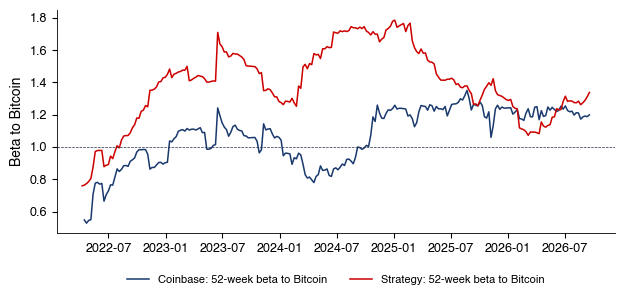

,Coinbase,Strategy
Weeks,283.000,284.000
Beta on Bitcoin,0.791,1.179
Beta on Bitcoin: standard error,0.089,0.109
Beta on the S&P 500,2.052,1.024
Beta on the S&P 500: standard error,0.221,0.241
R squared,0.515,0.630
Volatility (% a year),84.244,88.691
"Rolling 52-week beta on Bitcoin, latest",1.199,1.338
"Rolling beta, lowest",0.528,0.759
"Rolling beta, highest",1.350,1.785


In [17]:
def fig_crypto_equities(start='2021-04-16'):
    """Weekly two-factor regressions (Bitcoin, S&P 500) and the rolling 52-week beta to Bitcoin."""
    out = {}
    fig, ax = plt.subplots(figsize=(7.2, 2.9))
    for k in ['COIN', 'MSTR']:
        w = joint_returns([k, 'BTC', 'SPX'], start, freq='W')
        m = hac_ols(w[k], w[['BTC', 'SPX']])
        m1 = hac_ols(w[k], w['BTC'])
        cov = w[k].rolling(52).cov(w['BTC'])
        beta = (cov / w['BTC'].rolling(52).var()).dropna()
        ax.plot(beta.index, beta.values, color=COL[k], lw=1.1, label=f'{LABELS[k]}: 52-week beta to Bitcoin')
        out[k] = dict(n=len(w), a=52 * 100 * m.params['const'], b_btc=m.params['BTC'], se_btc=m.bse['BTC'],
                      b_spx=m.params['SPX'], se_spx=m.bse['SPX'], r2=m.rsquared, b1=m1.params['BTC'], r2_1=m1.rsquared,
                      vol=100 * w[k].std() * np.sqrt(52), beta_last=beta.iloc[-1], beta_min=beta.min(),
                      beta_max=beta.max(), corr=w[k].corr(w['BTC']))
    ax.axhline(1, color=Gray, lw=0.5, ls='--')
    ax.set_ylabel('Beta to Bitcoin')
    legend_outside_bottom(ax, ncol=2, y=-0.14)
    save_fig('ch16_crypto_equities')
    wb = joint_returns(['BTC', 'SPX'], start, freq='W')
    out['btc_vol'] = 100 * wb['BTC'].std() * np.sqrt(52)
    return out


eq = fig_crypto_equities()
table({k: eq[k] for k in ['COIN', 'MSTR']}, {'n': 'Weeks',
 'b_btc': 'Beta on Bitcoin',
 'se_btc': 'Beta on Bitcoin: standard error',
 'b_spx': 'Beta on the S&P 500',
 'se_spx': 'Beta on the S&P 500: standard error',
 'r2': 'R squared',
 'vol': 'Volatility (% a year)',
 'beta_last': 'Rolling 52-week beta on Bitcoin, latest',
 'beta_min': 'Rolling beta, lowest',
 'beta_max': 'Rolling beta, highest'}, {'COIN': 'Coinbase', 'MSTR': 'Strategy'})

## 8. Are cryptos becoming alternative assets?

- Tail, memory and moment features of 26 assets in two windows; principal components (PC); distances between class centroids.

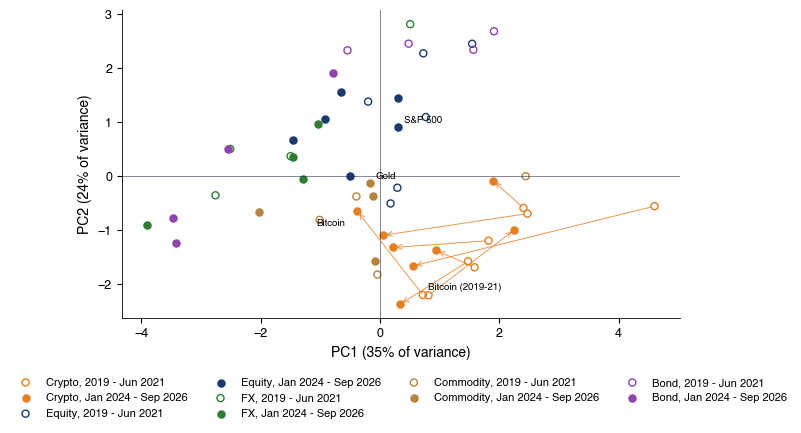

  Variance explained by PC1 (%)                         34.891
  Variance explained by PC2 (%)                         24.356
  Distance crypto - equities, W1 (2019 - June 2021)     3.026
  Distance crypto - commodities, W1 (2019 - June 2021)  2.262
  Distance crypto - currencies, W1 (2019 - June 2021)   4.248
  Distance crypto - bonds, W1 (2019 - June 2021)        4.326
  Dispersion within crypto, W1 (2019 - June 2021)       2.128
  Distance crypto - equities, W2 (spot-ETF era)         2.633
  Distance crypto - commodities, W2 (spot-ETF era)      1.857
  Distance crypto - currencies, W2 (spot-ETF era)       3.357
  Distance crypto - bonds, W2 (spot-ETF era)            3.706
  Dispersion within crypto, W2 (spot-ETF era)           1.426


In [18]:
WINDOWS = {'W1': ('2019-01-01', '2021-06-30'), 'W2': ('2024-01-11', '2026-09-18')}
FEATURES = ['ann_vol', 'skew', 'kurt', 'acf1', 'acf1_sq', 'hill_left', 'hill_right', 'mdd']


def asset_features(r, ppy=None):
    """Statistical features of a series of daily log returns (ppy: observations per year, by default the
    actual frequency of the series)."""
    ppy = periods_per_year(r) if ppy is None else ppy
    p = np.exp(r.cumsum())
    return dict(ann_vol=np.log(r.std() * np.sqrt(ppy)), skew=stats.skew(r), kurt=np.log1p(max(stats.kurtosis(r), 0)),
                acf1=r.autocorr(1), acf1_sq=(r ** 2).autocorr(1), hill_left=hill(-r.values - (-r).median()),
                hill_right=hill(r.values - r.median()), mdd=(p / p.cummax() - 1).min())


def feature_table():
    """Table of features by asset and window (W1: 2019 - June 2021; W2: the spot-ETF era)."""
    rows = []
    for s, (lab, cls, _) in CLASS_ASSETS.items():
        for w, (a, b) in WINDOWS.items():
            r = symbol_returns(s, a, b)
            rows.append(dict(symbol=s, label=lab, cls=cls, window=w, **asset_features(r)))
    return pd.DataFrame(rows)


def fig_alt_assets():
    """Principal components of the standardised features; distance between crypto and the traditional classes."""
    f = feature_table()
    X = f[FEATURES].values
    Z = (X - X.mean(0)) / X.std(0)
    U, S, Vt = np.linalg.svd(Z, full_matrices=False)
    pc = Z @ Vt[:2].T
    if np.corrcoef(pc[:, 0], f['ann_vol'])[0, 1] < 0:
        pc[:, 0] *= -1
        Vt[0] *= -1          # PC1 loadings with the same sign as the axis in the chart
    f['pc1'], f['pc2'] = pc[:, 0], pc[:, 1]
    ev = S ** 2 / (S ** 2).sum()
    fig, ax = plt.subplots(figsize=(7.2, 4.0))
    for cls, c in CLASS_COL.items():
        for w, mk, fc in [('W1', 'o', 'none'), ('W2', 'o', c)]:
            x = f[(f.cls == cls) & (f.window == w)]
            ax.scatter(x['pc1'], x['pc2'], s=26, marker=mk, facecolors=fc, edgecolors=c, lw=1.0,
                       label=f'{cls}, ' + ('2019 - Jun 2021' if w == 'W1' else 'Jan 2024 - Sep 2026'))
    for s in f[f.cls == 'Crypto'].symbol.unique():
        a = f[(f.symbol == s) & (f.window == 'W1')].iloc[0]
        b = f[(f.symbol == s) & (f.window == 'W2')].iloc[0]
        ax.annotate('', xy=(b.pc1, b.pc2), xytext=(a.pc1, a.pc2),
                    arrowprops=dict(arrowstyle='->', color=Orange, lw=0.7, alpha=0.8))
    for s, w, dx, dy in [('BTC-USD.CC', 'W1', 4, 4), ('BTC-USD.CC', 'W2', -30, -10), ('GSPC.INDX', 'W2', 4, 3),
                         ('XAUUSD.FOREX', 'W2', 4, 3)]:
        b = f[(f.symbol == s) & (f.window == w)].iloc[0]
        lab = b.label + (' (2019-21)' if w == 'W1' else '')
        ax.annotate(lab, (b.pc1, b.pc2), xytext=(dx, dy), textcoords='offset points', fontsize=7, color='black')
    ax.axhline(0, color=Gray, lw=0.4)
    ax.axvline(0, color=Gray, lw=0.4)
    ax.set_xlabel(f'PC1 ({100 * ev[0]:.0f}% of variance)')
    ax.set_ylabel(f'PC2 ({100 * ev[1]:.0f}% of variance)')
    legend_outside_bottom(ax, ncol=4, y=-0.16)
    save_fig('ch16_alt_assets')
    # distances in the full standardised space
    f[[f'z_{c}' for c in FEATURES]] = Z
    zc = [f'z_{c}' for c in FEATURES]
    out = dict(ev1=100 * ev[0], ev2=100 * ev[1], loadings={c: float(v) for c, v in zip(FEATURES, Vt[0])})
    for w in WINDOWS:
        g = f[f.window == w]
        cen = g.groupby('cls')[zc].mean()
        cr = g[g.cls == 'Crypto'][zc].values
        out[w] = dict(dist_equity=float(np.linalg.norm(cen.loc['Crypto'] - cen.loc['Equity'])),
                      dist_commodity=float(np.linalg.norm(cen.loc['Crypto'] - cen.loc['Commodity'])),
                      dist_fx=float(np.linalg.norm(cen.loc['Crypto'] - cen.loc['FX'])),
                      dist_bond=float(np.linalg.norm(cen.loc['Crypto'] - cen.loc['Bond'])),
                      spread_crypto=float(np.mean(np.linalg.norm(cr - cr.mean(0), axis=1))),
                      btc_vol=float(np.exp(g[g.symbol == 'BTC-USD.CC']['ann_vol'].iloc[0]) * 100),
                      crypto_kurt=float(np.expm1(g[g.cls == 'Crypto']['kurt']).median()))
    f.drop(columns=zc).to_csv(os.path.join(HERE, 'ch16_asset_features.csv'), index=False)
    return out


show(fig_alt_assets(), {'ev1': 'Variance explained by PC1 (%)',
 'ev2': 'Variance explained by PC2 (%)',
 'W1/dist_equity': 'Distance crypto - equities, W1 (2019 - June 2021)',
 'W1/dist_commodity': 'Distance crypto - commodities, W1 (2019 - June 2021)',
 'W1/dist_fx': 'Distance crypto - currencies, W1 (2019 - June 2021)',
 'W1/dist_bond': 'Distance crypto - bonds, W1 (2019 - June 2021)',
 'W1/spread_crypto': 'Dispersion within crypto, W1 (2019 - June 2021)',
 'W2/dist_equity': 'Distance crypto - equities, W2 (spot-ETF era)',
 'W2/dist_commodity': 'Distance crypto - commodities, W2 (spot-ETF era)',
 'W2/dist_fx': 'Distance crypto - currencies, W2 (spot-ETF era)',
 'W2/dist_bond': 'Distance crypto - bonds, W2 (spot-ETF era)',
 'W2/spread_crypto': 'Dispersion within crypto, W2 (spot-ETF era)'})

## 9. Inference

- Hill standard errors and confidence intervals (CI); $\sup$-Wald break test and Forbes–Rigobon correlation; equilibrium threshold AR (EQ-TAR, Balke & Fomby 1997) for the pegs with Hansen's bootstrap; LVR interval; block bootstrap of the asset-class map; Gibbons–Ross–Shanken (GRS) test and Fama–MacBeth with Shanken errors; Dimson betas.

In [19]:
TRIM = 0.15
COINS = ['BTC', 'ETH', 'XRP', 'BNB', 'ADA', 'DOGE', 'LTC', 'LINK']


def hill_k(x, k):
    """Hill estimator from the k largest positive values of x."""
    x = np.sort(x[x > 0])[::-1]
    return 1 / np.mean(np.log(x[:k] / x[k]))


def hill_inference(start='2018-01-01', B=1000, block=20):
    """alpha_H from the largest 5% of losses, asymptotic standard error alpha/sqrt(k) (i.i.d. data),
    95% CI, moving-block bootstrap CI (dependence), and alpha for k = 2.5% and 10%."""
    rng = np.random.default_rng(SEED)
    out = {}
    for key in STYL:
        r = 100 * np.log(price(key, start)).diff().dropna().values
        L = -r
        nl = int((L > 0).sum())
        k = max(int(0.05 * nl), 10)
        a = hill(L)
        se = a / np.sqrt(k)
        n = len(r)
        nb = int(np.ceil(n / block))
        bs = []
        for _ in range(B):
            st = rng.integers(0, n - block + 1, nb)
            y = r[(st[:, None] + np.arange(block)[None, :]).ravel()[:n]]
            bs.append(hill(-y))
        out[key] = dict(alpha=a, k=k, n_loss=nl, se=se, lo=a - 1.96 * se, hi=a + 1.96 * se,
                        b_lo=float(np.percentile(bs, 2.5)), b_hi=float(np.percentile(bs, 97.5)), b_se=float(np.std(bs)),
                        a25=hill_k(L, max(int(0.025 * nl), 10)), a10=hill_k(L, int(0.10 * nl)))
    for a, b in [('BTC', 'SPX'), ('BTC', 'GOLD'), ('DOGE', 'SPX')]:
        d = out[a]['alpha'] - out[b]['alpha']
        out[f'z_{a}_{b}'] = d / np.sqrt(out[a]['se'] ** 2 + out[b]['se'] ** 2)
    out['alpha_min'] = min(out[k]['alpha'] for k in STYL)
    out['alpha_max'] = max(out[k]['alpha'] for k in STYL)
    out['hi_max'] = max(out[k]['hi'] for k in STYL)
    return out


def nw_lags(T):
    """Number of Newey-West lags: floor(4 (T/100)^(2/9))."""
    return int(np.floor(4 * (T / 100) ** (2 / 9)))


def hac_meat(Z, u, L):
    """Long-run variance matrix of z_t u_t, Bartlett kernel with L lags."""
    g = Z * u[:, None]
    S = g.T @ g
    for l in range(1, L + 1):
        G = g[l:].T @ g[:-l]
        S += (1 - l / (L + 1)) * (G + G.T)
    return S


def sup_wald_crit(p, trim=TRIM, reps=20000, grid=1000, seed=SEED):
    """Asymptotic null distribution of sup-Wald (Andrews, 1993): sup ||B(r) - r B(1)||^2 / (r (1 - r)),
    B a p-dimensional Brownian motion, r in [trim, 1 - trim]; simulation."""
    rng = np.random.default_rng(seed)
    r = np.arange(1, grid + 1) / grid
    sel = (r >= trim) & (r <= 1 - trim)
    out = np.empty(reps)
    for i in range(reps):
        W = np.cumsum(rng.standard_normal((grid, p)), axis=0) / np.sqrt(grid)
        BB = W - r[:, None] * W[-1]
        out[i] = np.max((BB[sel] ** 2).sum(axis=1) / (r[sel] * (1 - r[sel])))
    return out


def sup_wald(y, X, index, trim=TRIM, lags=None):
    """sup-Wald test for a break in all coefficients of y = X b + u at an unknown date, with a HAC (Bartlett)
    covariance matrix computed separately in each regime; estimated date = minimum SSR (Bai, 1997)."""
    y, X = np.asarray(y, float), np.asarray(X, float)
    T, p = X.shape
    L = nw_lags(T) if lags is None else lags
    lo, hi = int(np.floor(trim * T)), int(np.ceil((1 - trim) * T))
    W, SSR = np.full(T, np.nan), np.full(T, np.nan)
    for tb in range(lo, hi):
        res = []
        V = np.zeros((p, p))
        ssr = 0.0
        for a, b in [(0, tb), (tb, T)]:
            Xa, ya = X[a:b], y[a:b]
            XtX = Xa.T @ Xa
            bet = np.linalg.solve(XtX, Xa.T @ ya)
            u = ya - Xa @ bet
            ssr += u @ u
            Q = np.linalg.inv(XtX)
            V += Q @ hac_meat(Xa, u, L) @ Q
            res.append(bet)
        d = res[1] - res[0]
        W[tb] = d @ np.linalg.solve(V, d)
        SSR[tb] = ssr
    tb_w = int(np.nanargmax(W))
    tb_hat = int(np.nanargmin(SSR))
    # Bai (1997) CI: (d'Q d)^2 / (d'Omega d) (T_hat - T0) -> argmax(W(s) - |s|/2); 97.5% quantile = 11
    b0 = np.linalg.lstsq(X[:tb_hat], y[:tb_hat], rcond=None)[0]
    b1 = np.linalg.lstsq(X[tb_hat:], y[tb_hat:], rcond=None)[0]
    d = b1 - b0
    u = y - np.where(np.arange(T)[:, None] < tb_hat, X @ b0[:, None], X @ b1[:, None]).ravel()
    Qm = X.T @ X / T
    Om = hac_meat(X, u, L) / T
    Lm = (d @ Qm @ d) ** 2 / (d @ Om @ d)
    half = int(np.ceil(11 / Lm)) + 1
    idx = pd.DatetimeIndex(index)
    return dict(sup_w=float(np.nanmax(W)), date_w=str(idx[tb_w].date()), date=str(idx[tb_hat].date()),
                ci_lo=str(idx[max(tb_hat - half, 0)].date()), ci_hi=str(idx[min(tb_hat + half, T - 1)].date()),
                half=half, b_pre=b0.tolist(), b_post=b1.tolist(), T=T, lags=L, W=W)


def break_btc_spx(start='2016-01-01'):
    """Break in the regression r_BTC = a + b r_SPX + u (common days, daily log returns); correlations before /
    after the estimated date; Forbes-Rigobon adjusted correlation relative to 2017-2019."""
    r = 100 * joint_returns(['BTC', 'SPX'], start)
    X = np.column_stack([np.ones(len(r)), r['SPX'].values])
    sw = sup_wald(r['BTC'].values, X, r.index)
    crit = sup_wald_crit(2)
    sw['p'] = float((crit >= sw['sup_w']).mean())
    sw['cv5'] = float(np.percentile(crit, 95))
    sw['cv1'] = float(np.percentile(crit, 99))
    W = pd.Series(sw.pop('W'), index=r.index)
    sw['W_etf'] = float(W.loc[ETF_START:].iloc[0])
    sw['W_date'] = float(W.loc[sw['date']])
    sw['start'] = str(r.index[0].date())
    pre, post = r.loc[:sw['date']].iloc[:-1], r.loc[sw['date']:]
    sw['rho_pre'], sw['rho_post'] = pre['BTC'].corr(pre['SPX']), post['BTC'].corr(post['SPX'])
    # Forbes-Rigobon: rho* = rho / sqrt(1 + delta (1 - rho^2)), delta = var_high / var_low - 1 (source market: S&P 500)
    per = {'p1': ('2017-01-01', '2019-12-31'), 'p2': ('2020-01-01', '2023-12-31'), 'p3': (ETF_START, END)}
    x = {k: r.loc[a:b] for k, (a, b) in per.items()}
    fr = {}
    for k in per:
        rho = x[k]['BTC'].corr(x[k]['SPX'])
        delta = x[k]['SPX'].var() / x['p1']['SPX'].var() - 1
        fr[k] = dict(rho=rho, delta=delta, rho_star=rho / np.sqrt(1 + delta * (1 - rho ** 2)), n=len(x[k]),
                     vol_spx=x[k]['SPX'].std() * np.sqrt(252))
    # block bootstrap for rho*_p2 - rho_p1 (each period resampled separately)
    rng = np.random.default_rng(SEED)
    def cbb(z):
        n = len(z)
        nb = int(np.ceil(n / 20))
        st = rng.integers(0, n - 19, nb)
        return z[(st[:, None] + np.arange(20)[None, :]).ravel()[:n]]
    a1, a2 = x['p1'].values, x['p2'].values
    dd = []
    for _ in range(2000):
        z1, z2 = cbb(a1), cbb(a2)
        r1 = np.corrcoef(z1.T)[0, 1]
        r2 = np.corrcoef(z2.T)[0, 1]
        dl = z2[:, 1].var() / z1[:, 1].var() - 1
        dd.append(r2 / np.sqrt(1 + dl * (1 - r2 ** 2)) - r1)
    fr['diff'] = fr['p2']['rho_star'] - fr['p1']['rho']
    fr['diff_lo'], fr['diff_hi'] = np.percentile(dd, [2.5, 97.5])
    sw['fr'] = fr
    return sw


print(table({k: v for k, v in hill_inference().items() if isinstance(v, dict)}, {'alpha': 'Hill tail index (largest 5% of losses)',
 'k': 'Losses used, k',
 'se': 'Asymptotic standard error',
 'lo': '95% CI, lower',
 'hi': '95% CI, upper',
 'b_lo': 'Block-bootstrap 95% CI, lower',
 'b_hi': 'Block-bootstrap 95% CI, upper',
 'a25': 'Hill index with k = 2.5% of losses',
 'a10': 'Hill index with k = 10% of losses'}, {'BTC': 'Bitcoin', 'ETH': 'Ether', 'SOL': 'Solana', 'DOGE': 'Dogecoin', 'SPX': 'S&P 500', 'GOLD': 'Gold'}, digits=2))
brk = break_btc_spx()
show(brk, {'sup_w': 'sup-Wald statistic',
 'cv5': '5% critical value',
 'p': 'p-value',
 'date': 'Least-squares break date',
 'ci_lo': 'Break date, 95% CI lower',
 'ci_hi': 'Break date, 95% CI upper',
 'W_date': 'Wald statistic at the break date',
 'W_etf': 'Wald statistic at the ETF launch',
 'rho_pre': 'Correlation before the break',
 'rho_post': 'Correlation after the break'})
show(brk['fr'], {'p1/rho': 'Correlation 2017-2019',
 'p2/rho': 'Correlation 2020-2023',
 'p2/rho_star': 'Forbes-Rigobon adjusted correlation 2020-2023',
 'p3/rho': 'Correlation since the spot ETFs',
 'p3/rho_star': 'Forbes-Rigobon adjusted correlation since the spot ETFs',
 'diff': 'Adjusted change, since the ETFs vs 2017-2019',
 'diff_lo': 'Change: 95% bootstrap CI lower',
 'diff_hi': 'Change: 95% bootstrap CI upper'})

                                        Bitcoin  Ether  Solana  Dogecoin  \
Hill tail index (largest 5% of losses)     2.73   2.67    2.85      2.83   
Losses used, k                            78.00  78.00   59.00     82.00   
Asymptotic standard error                  0.31   0.30    0.37      0.31   
95% CI, lower                              2.12   2.08    2.12      2.22   
95% CI, upper                              3.33   3.26    3.58      3.45   
Block-bootstrap 95% CI, lower              2.35   2.37    2.21      2.30   
Block-bootstrap 95% CI, upper              3.42   3.33    3.71      3.64   
Hill index with k = 2.5% of losses         3.48   3.73    2.61      2.49   
Hill index with k = 10% of losses          2.59   2.61    2.76      2.44   

                                        S&P 500   Gold  
Hill tail index (largest 5% of losses)     2.87   2.75  
Losses used, k                            49.00  50.00  
Asymptotic standard error                  0.41   0.39  
95% CI, low

  sup-Wald statistic                20.212
  5% critical value                 11.550
  p-value                           0.001
  Least-squares break date          2020-03-09
  Break date, 95% CI lower          2018-11-27
  Break date, 95% CI upper          2021-06-15
  Wald statistic at the break date  18.806
  Wald statistic at the ETF launch  2.315
  Correlation before the break      0.014
  Correlation after the break       0.400
  Correlation 2017-2019                                    0.023
  Correlation 2020-2023                                    0.392
  Forbes-Rigobon adjusted correlation 2020-2023            0.230
  Correlation since the spot ETFs                          0.384
  Forbes-Rigobon adjusted correlation since the spot ETFs  0.330
  Adjusted change, since the ETFs vs 2017-2019             0.207
  Change: 95% bootstrap CI lower                           0.085
  Change: 95% bootstrap CI upper                           0.336


In [20]:
def tar_fit(d, trim=TRIM, B=999, seed=SEED):
    """Equilibrium threshold AR (EQ-TAR, Balke & Fomby 1997): d_t = phi_in d_{t-1} + e_t if |d_{t-1}| <= c,
    d_t = phi_out d_{t-1} + e_t otherwise.
    Threshold c: grid search (values of |d_{t-1}| between the trim and 1 - trim quantiles), minimum SSR.
    Test H0: phi_in = phi_out (linear AR(1)), heteroskedasticity-robust sup-Wald; p-value by the fixed-regressor
    bootstrap y*_t = e_t eta_t, eta_t ~ N(0, 1), e_t the residuals of the linear model (H0) (Hansen, 1996).
    Only pairs (d_(t-1), d_t) on consecutive calendar days: if a period is removed from the series, no
    pair crosses the gap."""
    ok = np.diff(d.index.values).astype('timedelta64[D]') == np.timedelta64(1, 'D')
    y, x = d.values[1:][ok], d.values[:-1][ok]
    a = np.abs(x)
    order = np.argsort(a, kind='stable')
    xs, ys, as_ = x[order], y[order], a[order]
    n = len(y)
    x2 = xs ** 2
    lo, hi = int(np.floor(trim * n)), int(np.ceil((1 - trim) * n))
    # positions where the sample can be split (distinct values of |x|)
    cuts = np.array([i for i in range(lo, hi) if as_[i] < as_[i + 1]]) + 1   # the inner regime = the first i observations

    def wald(yy):
        c1 = np.cumsum(xs * yy)
        c2 = np.cumsum(x2)
        c3 = np.cumsum(x2 * yy ** 2)
        c4 = np.cumsum(xs ** 3 * yy)
        c5 = np.cumsum(xs ** 4)
        T1, T2, T3, T4, T5 = c1[-1], c2[-1], c3[-1], c4[-1], c5[-1]
        i = cuts - 1
        Sin, Sout = c2[i], T2 - c2[i]
        pin, pout = c1[i] / Sin, (T1 - c1[i]) / Sout
        vin = (c3[i] - 2 * pin * c4[i] + pin ** 2 * c5[i]) / Sin ** 2
        vout = ((T3 - c3[i]) - 2 * pout * (T4 - c4[i]) + pout ** 2 * (T5 - c5[i])) / Sout ** 2
        return (pin - pout) ** 2 / (vin + vout), pin, pout, vin, vout

    Wc, pin, pout, vin, vout = wald(ys)
    # threshold estimate: minimum SSR
    c1 = np.cumsum(xs * ys)
    c2 = np.cumsum(x2)
    i = cuts - 1
    ssr = np.sum(ys ** 2) - c1[i] ** 2 / c2[i] - (c1[-1] - c1[i]) ** 2 / (c2[-1] - c2[i])
    j = int(np.argmin(ssr))
    phi_lin = np.sum(x * y) / np.sum(x ** 2)
    e0 = ys - phi_lin * xs
    rng = np.random.default_rng(seed)
    sup0 = Wc.max()
    bs = np.array([wald(e0 * rng.standard_normal(n))[0].max() for _ in range(B)])
    hl = lambda p: float(np.log(0.5) / np.log(abs(p))) if 0 < abs(p) < 1 else None
    nin = int(cuts[j])
    return dict(n=n, c=float(as_[cuts[j] - 1]), n_in=nin, n_out=n - nin, share_out=100 * (n - nin) / n,
                phi_in=float(pin[j]), se_in=float(np.sqrt(vin[j])), phi_out=float(pout[j]), se_out=float(np.sqrt(vout[j])),
                hl_in=hl(pin[j]), hl_out=hl(pout[j]), phi_lin=float(phi_lin), hl_lin=hl(phi_lin),
                sup_w=float(sup0), p_boot=float((1 + (bs >= sup0).sum()) / (B + 1)), B=B,
                chi2_p=float(stats.chi2.sf(sup0, 1)), c_grid=[float(as_[cuts[0] - 1]), float(as_[cuts[-1] - 1])],
                share_var_out=float(100 * np.sum(x2[nin:]) / np.sum(x2)))


def peg_tar(start='2021-01-01'):
    """EQ-TAR for USDT, USDC, DAI: deviation of the daily close in basis points, 2021-2026."""
    out = {}
    for k in STABLE:
        d = 1e4 * (read_market(ASSETS[k][0]).loc[start:END, 'close'] - 1)
        out[k] = tar_fit(d)
    return out


def lvr_ci(start='2024-01-01', B=2000, block=20, seed=SEED):
    """Realised annual LVR rate (Milionis et al., 2022): the rebalancing portfolio holds every day the pool's
    ETH x = V/(2P); normalised daily loss (dR_t - dV_t)/V_(t-1) = R_t/2 - (sqrt(1 + R_t) - 1),
    R_t the simple return; rate = sum / years. sigma^2/8 from the variance of log returns; rv8 = sum R_t^2 / 8 / years;
    moving-block bootstrap interval for the realised rate, for sigma^2/8 and for the difference."""
    p = price('ETH', start)
    r = np.log(p).diff().dropna().values
    yrs = (p.index[-1] - p.index[0]).days / 365.25

    def rates(rr):
        R = np.expm1(rr)
        real = np.sum(R / 2 - (np.sqrt(1 + R) - 1)) / yrs
        theo = rr.var(ddof=1) * 365 / 8
        rv8 = np.sum(R ** 2) / 8 / yrs
        return 100 * real, 100 * theo, 100 * rv8
    real, theo, rv8 = rates(r)
    rng = np.random.default_rng(seed)
    n = len(r)
    nb = int(np.ceil(n / block))
    bs = []
    for _ in range(B):
        st = rng.integers(0, n - block + 1, nb)
        bs.append(rates(r[(st[:, None] + np.arange(block)[None, :]).ravel()[:n]]))
    bs = np.array(bs)
    return dict(real=real, theo=theo, rv8=rv8, lo=float(np.percentile(bs[:, 0], 2.5)), hi=float(np.percentile(bs[:, 0], 97.5)),
                t_lo=float(np.percentile(bs[:, 1], 2.5)), t_hi=float(np.percentile(bs[:, 1], 97.5)),
                d_lo=float(np.percentile(bs[:, 0] - bs[:, 1], 2.5)), d_hi=float(np.percentile(bs[:, 0] - bs[:, 1], 97.5)),
                corr=float(np.corrcoef(bs[:, 0], bs[:, 1])[0, 1]), n=n, years=yrs)


print(table(peg_tar(), {'n': 'Days',
 'c': 'Threshold c (bp)',
 'n_out': 'Days outside the band',
 'share_out': 'Share of days outside the band (%)',
 'phi_in': 'AR slope inside the band',
 'se_in': 'AR slope inside: White SE',
 'phi_out': 'AR slope outside the band',
 'se_out': 'AR slope outside: White SE',
 'hl_in': 'Half-life inside (days)',
 'hl_out': 'Half-life outside (days)',
 'phi_lin': 'Linear AR(1) slope',
 'sup_w': 'sup-Wald statistic',
 'p_boot': 'Bootstrap p-value',
 'chi2_p': 'Chi-squared(1) p-value (not valid here)',
 'share_var_out': 'Share of the sum of squared lagged deviations outside the band (%)'}, {'USDT': 'Tether', 'USDC': 'USD Coin', 'DAI': 'Dai'}))
show(lvr_ci(), {'real': 'Realised LVR rate (% a year)',
 'lo': 'Realised rate: 95% CI lower',
 'hi': 'Realised rate: 95% CI upper',
 'theo': 'sigma^2/8 (% a year)',
 't_lo': 'sigma^2/8: 95% CI lower',
 't_hi': 'sigma^2/8: 95% CI upper',
 'd_lo': 'Difference: 95% CI lower',
 'd_hi': 'Difference: 95% CI upper',
 'rv8': 'Realised variance / 8 (% a year)'})

                                                      Tether  USD Coin  \
Days                                                2086.000  2086.000   
Threshold c (bp)                                       8.569     2.865   
Days outside the band                                321.000   327.000   
Share of days outside the band (%)                    15.388    15.676   
AR slope inside the band                               0.864     0.586   
AR slope inside: White SE                              0.024     0.041   
AR slope outside the band                              0.689     0.283   
AR slope outside: White SE                             0.112     0.033   
Half-life inside (days)                                4.753     1.295   
Half-life outside (days)                               1.859     0.549   
Linear AR(1) slope                                     0.727     0.291   
sup-Wald statistic                                     7.443    32.499   
Bootstrap p-value                     

In [21]:
def class_distances(f):
    """Centroid distances (crypto vs classes) and crypto dispersion, by window, in the common standardised space."""
    X = f[FEATURES].values
    Z = (X - X.mean(0)) / X.std(0)
    zc = pd.DataFrame(Z, columns=FEATURES)
    zc['cls'], zc['window'] = f['cls'].values, f['window'].values
    out = {}
    for w in WINDOWS:
        g = zc[zc.window == w]
        cen = g.groupby('cls')[FEATURES].mean()
        cr = g[g.cls == 'Crypto'][FEATURES].values
        out[w] = dict(eq=np.linalg.norm(cen.loc['Crypto'] - cen.loc['Equity']),
                      com=np.linalg.norm(cen.loc['Crypto'] - cen.loc['Commodity']),
                      fx=np.linalg.norm(cen.loc['Crypto'] - cen.loc['FX']),
                      bond=np.linalg.norm(cen.loc['Crypto'] - cen.loc['Bond']),
                      spread=np.mean(np.linalg.norm(cr - cr.mean(0), axis=1)))
    return out


def alt_bootstrap(B=500, block=28, seed=SEED):
    """Moving-block bootstrap common to all assets: in each window, blocks of 28 calendar days
    (4 weeks = 20 weekdays) are drawn and each asset takes its own returns (on its own calendar)
    from the same days, so the dependence between assets is kept; features recomputed, common
    standardisation, the change W2 - W1 in the distances; 95% percentile CI."""
    rng = np.random.default_rng(seed)
    base = []
    series = {}
    for s, (lab, cls, _) in CLASS_ASSETS.items():
        for w, (a, b) in WINDOWS.items():
            r = symbol_returns(s, a, b)
            series[(s, w)] = r
            base.append(dict(symbol=s, cls=cls, window=w, **asset_features(r)))
    f0 = pd.DataFrame(base)
    d0 = class_distances(f0)
    cal = {w: pd.date_range(min(r.index[0] for (s, ww), r in series.items() if ww == w),
                            max(r.index[-1] for (s, ww), r in series.items() if ww == w), freq='D') for w in WINDOWS}
    ppy = {k: periods_per_year(r) for k, r in series.items()}
    draws = []
    for _ in range(B):
        rows = []
        for w, days in cal.items():
            n = len(days)
            st = rng.integers(0, n - block + 1, int(np.ceil(n / block)))
            sel = days[(st[:, None] + np.arange(block)[None, :]).ravel()[:n]]      # the same days for all assets
            for (s, ww), r in series.items():
                if ww != w:
                    continue
                rr = r.reindex(sel).dropna()
                rows.append(dict(symbol=s, cls=CLASS_ASSETS[s][1], window=w, **asset_features(rr, ppy[(s, w)])))
        d = class_distances(pd.DataFrame(rows))
        draws.append({k: d['W2'][k] - d['W1'][k] for k in d['W1']})
    D = pd.DataFrame(draws)
    out = {}
    for k in D:
        out[k] = dict(w1=d0['W1'][k], w2=d0['W2'][k], diff=d0['W2'][k] - d0['W1'][k],
                      lo=float(D[k].quantile(0.025)), hi=float(D[k].quantile(0.975)), share_pos=float((D[k] >= 0).mean()))
    hl = f0[f0.cls == 'Crypto'].groupby('window')['hill_left'].median()
    out['hill_crypto'] = {w: float(hl[w]) for w in WINDOWS}
    out['hill_crypto_n_below4'] = {w: int((f0[(f0.cls == 'Crypto') & (f0.window == w)]['hill_left'] < 4).sum())
                                   for w in WINDOWS}
    out['B'] = B
    return out


def weekly_rf():
    """Weekly risk-free rate from the 4-week Treasury bill yield (FRED DTB4WK, % a year)."""
    s = pd.read_csv('https://fred.stlouisfed.org/graph/fredgraph.csv?id=DTB4WK', index_col=0, parse_dates=True).iloc[:, 0]
    s = pd.to_numeric(s, errors='coerce').dropna()
    return (s / 100 / 52).resample('W-FRI').last().ffill()


def grs_test(R, f):
    """GRS = (T - N - K)/N * a' S^-1 a / (1 + m' O^-1 m) ~ F(N, T - N - K) under i.i.d. errors with the Normal
    distribution; S, O maximum-likelihood estimators (division by T)."""
    T, N = R.shape
    K = f.shape[1]
    X = np.column_stack([np.ones(T), f])
    B = np.linalg.lstsq(X, R, rcond=None)[0]
    E = R - X @ B
    S = E.T @ E / T
    m = f.mean(0)
    O = np.atleast_2d(np.cov(f.T, bias=True))
    a = B[0]
    stat = (T - N - K) / N * (a @ np.linalg.solve(S, a)) / (1 + m @ np.linalg.solve(O, m))
    return stat, B, E


def asset_pricing(start='2018-01-05', Bb=2000, seed=SEED):
    """Eight coins, weekly simple excess returns (Friday); market factor = the market-value weighted total index
    (5 coins with a public circulating supply), in excess of the risk-free rate.
    GRS with the F p-value and a wild-bootstrap p-value (Rademacher by row, under H0: alpha = 0);
    Fama-MacBeth: first-stage betas on the full sample, weekly cross-sectional regressions; FM and Shanken errors."""
    tot, _ = crix_index(None, 'cap')
    p = pd.concat([price(c) for c in COINS] + [tot.rename('MKT')], axis=1).dropna()
    w = p.resample('W-FRI').last().pct_change().dropna().loc[start:END]
    rf = weekly_rf().reindex(w.index).ffill()
    ex = w.sub(rf, axis=0).dropna()
    R, f = ex[COINS].values, ex[['MKT']].values
    T, N = R.shape
    K = 1
    stat, Bc, E = grs_test(R, f)
    p_f = float(stats.f.sf(stat, N, T - N - K))
    rng = np.random.default_rng(seed)
    X = np.column_stack([np.ones(T), f])
    fit0 = X[:, 1:] @ Bc[1:]
    bs = []
    for _ in range(Bb):
        eta = rng.choice([-1.0, 1.0], T)[:, None]
        bs.append(grs_test(fit0 + E * eta, f)[0])
    p_boot = float((1 + (np.array(bs) >= stat).sum()) / (Bb + 1))
    beta = Bc[1]
    alpha_ann = 52 * 100 * Bc[0]
    # Fama-MacBeth
    Xc = np.column_stack([np.ones(N), beta])
    G = np.array([np.linalg.lstsq(Xc, R[t], rcond=None)[0] for t in range(T)])
    gam = G.mean(0)
    se_fm = G.std(0, ddof=1) / np.sqrt(T)
    Sig = E.T @ E / T
    sf = f.var(ddof=1)
    lam = gam[1]
    A = np.linalg.inv(Xc.T @ Xc) @ Xc.T
    V = (A @ Sig @ A.T) * (1 + lam ** 2 / sf) / T + np.diag([0.0, sf]) / T
    se_sh = np.sqrt(np.diag(V))
    return dict(T=T, N=N, K=K, start=str(ex.index[0].date()), end=str(ex.index[-1].date()),
                grs=float(stat), p_f=p_f, p_boot=p_boot, B=Bb, beta={c: float(b) for c, b in zip(COINS, beta)},
                alpha={c: float(a) for c, a in zip(COINS, alpha_ann)},
                alpha_t={c: float(a / s) for c, a, s in zip(COINS, Bc[0], np.sqrt(np.diag(Sig) / T * (1 + (f.mean() ** 2) / f.var(ddof=0))))},
                g0=float(52 * 100 * gam[0]), g1=float(52 * 100 * gam[1]), se_fm0=float(52 * 100 * se_fm[0]),
                se_fm1=float(52 * 100 * se_fm[1]), se_sh0=float(52 * 100 * se_sh[0]), se_sh1=float(52 * 100 * se_sh[1]),
                t_fm1=float(gam[1] / se_fm[1]), t_sh1=float(gam[1] / se_sh[1]), mkt_ann=float(52 * 100 * f.mean()),
                mkt_t=float(f.mean() / (f.std(ddof=1) / np.sqrt(T))), shanken_c=float(lam ** 2 / sf),
                hill_mkt=float(hill(-f.ravel())), beta_min=float(beta.min()), beta_max=float(beta.max()))


def dimson(etf='IBIT', coin='BTC'):
    """r_ETF,t = a + b_-1 r_coin,t-1 + b_0 r_coin,t + b_+1 r_coin,t+1 + u_t, on common days; Dimson beta = the sum,
    Newey-West standard error."""
    r = 100 * joint_returns([etf, coin])
    X = pd.concat([r[coin].shift(1).rename('lag'), r[coin].rename('now'), r[coin].shift(-1).rename('lead')], axis=1)
    d = pd.concat([r[etf], X], axis=1).dropna()
    m = sm.OLS(d[etf], sm.add_constant(d[['lag', 'now', 'lead']])).fit(cov_type='HAC', cov_kwds={'maxlags': 5})
    R = np.array([0, 1, 1, 1])
    s = float(R @ m.params.values)
    se = float(np.sqrt(R @ m.cov_params().values @ R))
    m0 = sm.OLS(d[etf], sm.add_constant(d['now'])).fit(cov_type='HAC', cov_kwds={'maxlags': 5})
    return dict(n=len(d), b_lag=float(m.params['lag']), b_now=float(m.params['now']), b_lead=float(m.params['lead']),
                se_lead=float(m.bse['lead']), sum=s, se=se, t1=(s - 1) / se, b_ols=float(m0.params['now']),
                se_ols=float(m0.bse['now']), r2=float(m.rsquared))


bs = alt_bootstrap(B=200)
print(table({k: bs[k] for k in ['eq', 'com', 'fx', 'bond', 'spread']}, {'w1': 'Distance, W1',
 'w2': 'Distance, W2',
 'diff': 'Change W2 - W1',
 'lo': 'Change: 95% CI lower',
 'hi': 'Change: 95% CI upper',
 'share_pos': 'Share of positive bootstrap changes'}, {'eq': 'Crypto vs equities',
 'com': 'Crypto vs commodities',
 'fx': 'Crypto vs currencies',
 'bond': 'Crypto vs bonds',
 'spread': 'Dispersion within crypto'}))
ap = asset_pricing()
show(ap, {'T': 'Weeks',
 'N': 'Coins',
 'grs': 'GRS statistic',
 'p_f': 'GRS p-value, F distribution',
 'p_boot': 'GRS p-value, wild bootstrap',
 'g1': 'Fama-MacBeth market premium (% a year)',
 'se_fm1': 'Fama-MacBeth standard error',
 'se_sh1': 'Shanken standard error',
 'mkt_ann': 'Mean market factor (% a year)',
 'mkt_t': 't-statistic of the market factor'})
print(pd.DataFrame({'Beta': ap['beta'], 'Alpha (% a year)': ap['alpha'], 't-statistic of alpha': ap['alpha_t']}).round(2))
table({'IBIT vs Bitcoin': dimson('IBIT', 'BTC'), 'ETHA vs Ether': dimson('ETHA', 'ETH')}, {'n': 'Common days',
 'b_lag': 'Beta on the previous-day coin return',
 'b_now': 'Beta, same day',
 'b_lead': 'Beta on the next-day coin return',
 'sum': 'Dimson sum beta',
 'se': 'Dimson sum beta: standard error',
 't1': 't-statistic for beta = 1',
 'b_ols': 'OLS beta',
 'r2': 'R squared'})

                                     Crypto vs equities  \
Distance, W1                                      3.026   
Distance, W2                                      2.633   
Change W2 - W1                                   -0.394   
Change: 95% CI lower                             -1.040   
Change: 95% CI upper                              0.577   
Share of positive bootstrap changes               0.295   

                                     Crypto vs commodities  \
Distance, W1                                         2.262   
Distance, W2                                         1.857   
Change W2 - W1                                      -0.405   
Change: 95% CI lower                                -1.380   
Change: 95% CI upper                                 0.445   
Share of positive bootstrap changes                  0.150   

                                     Crypto vs currencies  Crypto vs bonds  \
Distance, W1                                        4.248            4.32

  Weeks                                   450
  Coins                                   8
  GRS statistic                           2.161
  GRS p-value, F distribution             0.029
  GRS p-value, wild bootstrap             0.018
  Fama-MacBeth market premium (% a year)  163.236
  Fama-MacBeth standard error             147.028
  Shanken standard error                  155.602
  Mean market factor (% a year)           39.387
  t-statistic of the market factor        1.811
      Beta  Alpha (% a year)  t-statistic of alpha
BTC   0.96              4.70                  1.22
ETH   1.14             -1.53                 -0.12
XRP   0.94             11.83                  0.41
BNB   0.90             50.81                  1.97
ADA   1.14             -6.24                 -0.26
DOGE  1.40             99.29                  1.23
LTC   1.05            -17.86                 -1.01
LINK  1.12             47.75                  1.69


,IBIT vs Bitcoin,ETHA vs Ether
Common days,671.000,539.000
Beta on the previous-day coin return,0.051,0.057
"Beta, same day",0.938,0.938
Beta on the next-day coin return,0.009,-0.003
Dimson sum beta,0.998,0.992
Dimson sum beta: standard error,0.023,0.022
t-statistic for beta = 1,-0.071,-0.349
OLS beta,0.935,0.938
R squared,0.826,0.828
